# Walk-Forward Backtest — Sistema Turtle sobre futuros diversificados

**Fuente de reglas:** skill `/turtlerisk` + *The Original Turtle Trading Rules* (Curtis Faith, 2003)
**Universo:** constituyentes del índice Coinbase 50 (COIN50), MarketVector/Coinbase
**Datos:** Binance USD-M Futures (`fapi.binance.com`), Interactive Brokers, Yahoo Finance velas diarias
**Benchmark:** COIN50 index — CAGR 15.34%, Sharpe 0.48, Max DD −78.28%, Vol 63.91% (Ene 2021 – May 2026)

---

## ⚠️ LEE ESTO ANTES DE INTERPRETAR CUALQUIER RESULTADO

Este notebook está construido para ser **honesto**, no para producir una curva bonita. Cuatro
sesgos van a inflar los resultados si no los controlas, y tres están **activamente medidos** aquí:

| # | Sesgo | Impacto | Control en este notebook |
|---|-------|---------|--------------------------|
| 1 | **Survivorship bias** | 🔴 Severo | El universo es la composición **actual** (Ago-2026). Los tokens que COIN50 expulsó por colapsar no están. Backtestear 2021→2026 sobre los sobrevivientes de hoy infla el retorno. **Medido** en §7 con el test de listing-date. |
| 2 | **Look-ahead en canales** | 🟠 Alto | Todos los canales Donchian usan `.shift(1)`. El canal de hoy se calcula con datos hasta **ayer**. |
| 3 | **Overfitting del walk-forward** | 🔴 Severo | Turtle tiene ~4 parámetros y fue diseñado para **no** optimizarse. §6 compara WFO vs. parámetros canónicos fijos. **Si el WFO no le gana a los fijos, la optimización es ruido.** |
| 4 | **Costes ignorados** | 🟠 Alto | Fees + slippage + **funding** de perpetuos modelados explícitamente. El funding sobre posiciones de tendencia mantenidas meses es material. |

**El diagnóstico más importante del notebook está en §6.** No mires el Sharpe. Mira si el
walk-forward optimizado le gana a los parámetros que Richard Dennis fijó en 1983 sin optimizar nada.


## 1. Setup y configuración

Los parámetros móviles y que se pueden optimizar quedan en este segmento. Es bien sabido que la estrategia original dejó de producir buenos resultados luego de la entrada en vigor  el mercado electrónico de derivados y la aparición de los High Frequency Traders. Sin embargo mercados como las criptomonedas donde HFT e inversionistas institucionales aún no tienen una presencia dominante y muestran fragmentación , la estrategia puede generar resultados favorables , más aún teniendo en cuenta las bajas comisiones  que ofrecen algunos canales de negociación.

In [28]:
# pip install requests pandas numpy matplotlib scipy tqdm
import json, sys, time, warnings, itertools
from dataclasses import dataclass, field
from datetime import datetime, timezone, timedelta
from pathlib import Path
from __future__ import annotations

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 50)

plt.rcParams.update({
    "figure.figsize": (14, 6), "axes.grid": True, "grid.alpha": 0.25,
    "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
})

ROOT = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
CACHE = ROOT / "data_cache"; CACHE.mkdir(exist_ok=True)
sys.path.insert(0, str(ROOT))   # necesario para `from src.data... import ...` (§3 en adelante)
print("Setup OK")

Setup OK


In [29]:
# ─────────── PARÁMETROS CANÓNICOS TURTLE (skill /turtlerisk) ───────────
ATR_PERIOD    = 20        # N = EMA-20 del True Range
RISK_PER_UNIT = 0.01      # 1% del equity por unidad
MAX_UNITS     = 4         # máx. unidades por mercado
STOP_N        = 1.0       # stop a 2N  → 2% de riesgo por unidad
ADD_N         = 0.5       # añadir unidad cada ½N
MAX_DIR_UNITS = 12        # máx. unidades por dirección
MAX_CORR_UNITS = 6        # máx. unidades por grupo correlacionado
MAX_GROSS_LEV  = 4.0      # tope de nocional bruto / equity (§5)

# Sistema 1 (corto) / Sistema 2 (largo)
SYS1 = {"entry": 20, "exit": 10}
SYS2 = {"entry": 55, "exit": 20}

# ─────────── COSTES DE EJECUCIÓN (Binance USD-M) ───────────
TAKER_FEE   = 0.0005      # 5 bps taker
SLIPPAGE    = 0.0010      # 10 bps — breakouts se llenan mal por definición
FUNDING_DIA = 0.0001 * 3  # ~1 bp × 3 pagos/día ≈ 3 bps/día ≈ 11%/año

EQUITY_0    = 10_000
START_DATE  = "2025-12-01"   # base del índice COIN50

print(f"Coste round-trip: {2*(TAKER_FEE+SLIPPAGE)*1e4:.0f} bps | Funding: {FUNDING_DIA*365*100:.1f}%/año")

Coste round-trip: 30 bps | Funding: 11.0%/año


## 2. Universo — categorías mayores diversificadas

Prelación contratos de menor cuantía (CFD's y Perpetuals)

**Aquí nace el sesgo #1.** Se usan solamente contratos disponibles en futuros CFD en Interactive Brokers o Yahoo Finance. Activos que han desaparecido o no estén disponibles quedan fuera de la muestra

In [30]:
# Tabla maestra de contratos (Llave por ticker de bolsa, valor por ticker de broker/plataforma)
UNIVERSE: Dict[str, dict] = {
    # ---------------- COMMODITIES ----------------
    "BC": {"desc": "Brent Crude Oil",      "yahoo": "BZ=F", "ib": "BZ",  "ib_micro": None,  "binance": "BZ"},
    "BG": {"desc": "Brent Gasoil (ICE)",   "yahoo": None,   "ib": "GAS", "ib_micro": None,  "binance": None},
    "CC": {"desc": "Cocoa",                "yahoo": "CC=F", "ib": "CC",  "ib_micro": None,  "binance": None},
    "CL": {"desc": "Crude Oil (WTI)",      "yahoo": "CL=F", "ib": "CL",  "ib_micro": "MCL", "binance": "CL"},
    "CT": {"desc": "Cotton #2",            "yahoo": "CT=F", "ib": "CT",  "ib_micro": None,  "binance": None},
    "DA": {"desc": "Milk Class III",       "yahoo": "DC=F", "ib": "DC",  "ib_micro": None,  "binance": None},
    "GI": {"desc": "S&P GSCI",             "yahoo": "GD=F", "ib": None,  "ib_micro": None,  "binance": None},
    "JO": {"desc": "Orange Juice",         "yahoo": "OJ=F", "ib": "OJ",  "ib_micro": None,  "binance": None},
    "KC": {"desc": "Coffee",               "yahoo": "KC=F", "ib": "KC",  "ib_micro": None,  "binance": None},
    "KW": {"desc": "Wheat (KC / KCBT)",    "yahoo": "KE=F", "ib": "KE",  "ib_micro": None,  "binance": None},
    "NR": {"desc": "Natural Gas",          "yahoo": "NG=F", "ib": "NG",  "ib_micro": "QG",  "binance": "NATGAS"},
    "SB": {"desc": "Sugar #11",            "yahoo": "SB=F", "ib": "SB",  "ib_micro": None,  "binance": None},
    "W_": {"desc": "Wheat, CBOT",          "yahoo": "ZW=F", "ib": "ZW",  "ib_micro": "XW",  "binance": None},
    "ZA": {"desc": "Palladium",            "yahoo": "PA=F", "ib": "PA",  "ib_micro": None,  "binance": None},
    "ZB": {"desc": "RBOB Gasoline",        "yahoo": "RB=F", "ib": "RB",  "ib_micro": None,  "binance": None},
    "ZC": {"desc": "Corn",                 "yahoo": "ZC=F", "ib": "ZC",  "ib_micro": "XC",  "binance": None},
    "ZF": {"desc": "Feeder Cattle",        "yahoo": "GF=F", "ib": "GF",  "ib_micro": None,  "binance": None},
    "ZG": {"desc": "Gold",                 "yahoo": "GC=F", "ib": "GC",  "ib_micro": "MGC", "binance": "XAU"},
    "ZI": {"desc": "Silver",               "yahoo": "SI=F", "ib": "SI",  "ib_micro": None,  "binance": "XAG"},
    "ZK": {"desc": "Copper",               "yahoo": "HG=F", "ib": "HG",  "ib_micro": "MHG", "binance": None},
    "ZL": {"desc": "Soybean Oil",          "yahoo": "ZL=F", "ib": "ZL",  "ib_micro": None,  "binance": None},
    "ZM": {"desc": "Soybean Meal",         "yahoo": "ZM=F", "ib": "ZM",  "ib_micro": None,  "binance": None},
    "ZN": {"desc": "Natural Gas (elec.)",  "yahoo": "NG=F", "ib": "NG",  "ib_micro": "QG",  "binance": "NATGAS"},
    "ZO": {"desc": "Oats",                 "yahoo": "ZO=F", "ib": "ZO",  "ib_micro": None,  "binance": None},
    "ZP": {"desc": "Platinum",             "yahoo": "PL=F", "ib": "PL",  "ib_micro": None,  "binance": None},
    "ZR": {"desc": "Rough Rice",           "yahoo": "ZR=F", "ib": "ZR",  "ib_micro": None,  "binance": None},
    "ZS": {"desc": "Soybeans",             "yahoo": "ZS=F", "ib": "ZS",  "ib_micro": "XK",  "binance": None},
    "ZT": {"desc": "Live Cattle",          "yahoo": "LE=F", "ib": "LE",  "ib_micro": None,  "binance": None},
    "ZU": {"desc": "Crude Oil (elec.)",    "yahoo": "CL=F", "ib": "CL",  "ib_micro": "MCL", "binance": "CL"},
    "ZW": {"desc": "Wheat (elec., CBOT)",  "yahoo": "ZW=F", "ib": "ZW",  "ib_micro": "XW",  "binance": None},
    "ZZ": {"desc": "Lean Hogs",            "yahoo": "HE=F", "ib": "HE",  "ib_micro": None,  "binance": None},

    # ---------------- EQUITY INDEX ----------------
    # (Yahoo: US e-mini como futuro "=F"; europeos/asiáticos como índice cash "^")
    "AX": {"desc": "German DAX",           "yahoo": "^GDAXI",   "ib": "DAX",    "ib_micro": None,  "binance": None},
    "CA": {"desc": "CAC 40",               "yahoo": "^FCHI",    "ib": "CAC40",  "ib_micro": None,  "binance": None},
    "EN": {"desc": "Nasdaq-100 e-mini",    "yahoo": "NQ=F",     "ib": "NQ",     "ib_micro": "MNQ", "binance": None},
    "ER": {"desc": "Russell 2000 e-mini",  "yahoo": "RTY=F",    "ib": "RTY",    "ib_micro": "M2K", "binance": None},
    "ES": {"desc": "S&P 500 e-mini",       "yahoo": "ES=F",     "ib": "ES",     "ib_micro": "MES", "binance": None},
    "HS": {"desc": "Hang Seng",            "yahoo": "^HSI",     "ib": "HSI",    "ib_micro": "MHI", "binance": None},
    "LX": {"desc": "FTSE 100",             "yahoo": "^FTSE",    "ib": "Z",      "ib_micro": None,  "binance": None},
    "SP": {"desc": "S&P 500 (day session)","yahoo": "ES=F",     "ib": "ES",     "ib_micro": "MES", "binance": None},
    "XU": {"desc": "EURO STOXX 50",        "yahoo": "^STOXX50E","ib": "ESTX50", "ib_micro": None,  "binance": None},
    "YM": {"desc": "DJIA e-mini ($5)",     "yahoo": "YM=F",     "ib": "YM",     "ib_micro": "MYM", "binance": None},
    "VX": {"desc": "VIX",                  "yahoo": "^VIX","ib": "VX","ib_micro": None, "binance": None},

    # ---------------- FIXED INCOME ----------------
    "AP": {"desc": "Australian price index","yahoo": None,  "ib": None,  "ib_micro": None, "binance": None},
    "DT": {"desc": "Euro Bund (Eurex)",     "yahoo": None,  "ib": "GBL", "ib_micro": None, "binance": None},
    "FB": {"desc": "T-Note 5yr",            "yahoo": "ZF=F","ib": "ZF",  "ib_micro": None, "binance": None},
    "GS": {"desc": "Long Gilt",             "yahoo": None,  "ib": "R",   "ib_micro": None, "binance": None},
    "TU": {"desc": "T-Note 2yr",            "yahoo": "ZT=F","ib": "ZT",  "ib_micro": None, "binance": None},
    "TY": {"desc": "T-Note 10yr",           "yahoo": "ZN=F","ib": "ZN",  "ib_micro": None, "binance": None},
    "US": {"desc": "T-Bond 30yr",           "yahoo": "ZB=F","ib": "ZB",  "ib_micro": None, "binance": None},

    # ---------------- CURRENCIES / OTROS ----------------
    "AN": {"desc": "Australian Dollar",    "yahoo": "6A=F", "ib": "6A", "ib_micro": "M6A", "binance": None},
    "BN": {"desc": "British Pound",        "yahoo": "6B=F", "ib": "6B", "ib_micro": "M6B", "binance": None},
    "CN": {"desc": "Canadian Dollar",      "yahoo": "6C=F", "ib": "6C", "ib_micro": None,  "binance": None},
    "DX": {"desc": "US Dollar Index",      "yahoo": "DX=F", "ib": "DX", "ib_micro": None,  "binance": None},
    "FN": {"desc": "Euro FX",              "yahoo": "6E=F", "ib": "6E", "ib_micro": "M6E", "binance": None},
    "JN": {"desc": "Japanese Yen",         "yahoo": "6J=F", "ib": "6J", "ib_micro": None,  "binance": None},
    "NK": {"desc": "Nikkei 225",           "yahoo": "^N225","ib": "N225","ib_micro": None, "binance": None},
    "SN": {"desc": "Swiss Franc",          "yahoo": "6S=F", "ib": "6S", "ib_micro": None,  "binance": None},

    # ---------------- CRYPTOCURRENCIES ----------------
    "BTC": {"desc": "Bitcoin",              "yahoo": "BTC-USD",   "ib": "BTC","ib_micro": None,  "binance": None},
    "ETH": {"desc": "Ethereum",             "yahoo": "ETH-USD",   "ib": "ETH","ib_micro": None,  "binance": None},
    "LTC": {"desc": "Litecoin",             "yahoo": "LTC-USD",   "ib": "LTC","ib_micro": None,  "binance": None},
    "XRP": {"desc": "Ripple",               "yahoo": "XRP-USD",   "ib": "XRP","ib_micro": None,  "binance": None},
    "BCH": {"desc": "Bitcoin Cash",         "yahoo": "BCH-USD",   "ib": "BCH","ib_micro": None,  "binance": None},
    "LINK": {"desc": "Chainlink",          "yahoo": "LINK-USD",   "ib": "LINK","ib_micro": None,  "binance": None},
    "DOT": {"desc": "Polkadot",            "yahoo": "DOT-USD",   "ib": "DOT","ib_micro": None,  "binance": None},
    "ADA": {"desc": "Cardano",             "yahoo": "ADA-USD",   "ib": "ADA","ib_micro": None,  "binance": None},
    "SOL": {"desc": "Solana",              "yahoo": "SOL-USD",   "ib": "SOL","ib_micro": None,  "binance": None},
    "AVAX": {"desc": "Avalanche",         "yahoo": "AVAX-USD",   "ib": "AVAX","ib_micro": None,  "binance": None},
    "MATIC": {"desc": "Polygon",          "yahoo": "MATIC-USD",   "ib": "MATIC","ib_micro": None,  "binance": None},
}

# Grupos de correlación (skill /turtlerisk §2, extendido al universo )
CORRELATION_GROUPS = {
    "commodities": {"BC","BG","CC","CL","CT","DA","GI","JO","KC","KW","LB","NR","SB","W_","ZA","ZB","ZC","ZF","ZG","ZI","ZK","ZL","ZM","ZN","ZO","ZP","ZR","ZS","ZT","ZU","ZW","ZZ"},
    "equity":   {"AX","CA","EN","ES","US","YM","ER","HS","LX","SC","SP","XU","VX"},
    "fixed_income": {"AP","DT","FB","GS","TU","TY","UB","US"},
    "currencies": {"AN","BN","CB","CN","DX","FN","JN","MP","NK","SN"},
    "crypto":   {"BTC","ETH","XRP","SOL","DOGE","ZEC","ADA","LINK","XLM","BCH",
    "LTC","AVAX","SHIB","UNI","NEAR","AAVE","DOT","ICP","ETC","QNT",
    "ALGO","ATOM","RENDER","INJ","CRV","STX","LDO","XTZ","IMX","BONK",
    "JASMY","AXS","GRT","CHZ","APE","MANA","SAND","SNX","EGLD",
    "LPT","KSM","MINA","ROSE","BLUR","HNT","EOS","MKR","MATIC"}
}
SYM2GROUP = {s: g for g, ms in CORRELATION_GROUPS.items() for s in ms}

print(f"{len(UNIVERSE)} activos | {len(CORRELATION_GROUPS)} grupos de correlación")
assert all(s in SYM2GROUP for s in UNIVERSE), [s for s in UNIVERSE if s not in SYM2GROUP]
print("✓ Todos los activos tienen grupo asignado")

68 activos | 5 grupos de correlación
✓ Todos los activos tienen grupo asignado


## 3. Descarga de datos — Binance + Yahoo, serie más larga por símbolo

Se usa `src.data.fetcher.BinanceFetcher` y `YahooFinanceFetcher`: las mismas clases que
alimentan el scanner y el sheet de riesgo (skill `/data-manager`), no una reimplementación
de la paginación de ninguna API. Para cada clave de `UNIVERSE` en el grupo `"crypto"`,
`load_symbol()` pide el perpetuo nativo en Binance (`{BASE}USDT`) y, si `UNIVERSE[base]`
trae un ticker Yahoo (`{BASE}-USD`), también ese spot — y se queda con el que dé **más
barras**, no con el primero que responda. Binance USD-M no lista casi ningún símbolo antes
de 2019-2020; Yahoo suele tener spot desde 2014-2017 según el activo, así que a menudo gana
Yahoo en profundidad aunque Binance sea la fuente "natural" del perpetuo.

Cada símbolo pasa además por `processor.DataProcessor.clean_data()` (dedup + descarta
filas con NaN en OHLC, sin relleno sintético) y por `validator.DataValidator.validate_all()`:
un símbolo con precios inválidos, huecos severos o duplicados **no entra** a `RAW` — se
descarta con motivo explícito en `ERR`, en vez de colarse y romper algo varias celdas
más abajo.

La caché deja de ser el parquet plano de antes (`data_cache/BTCUSDT.parquet`): pasa a la
convención de `BaseFetcher` (`data_cache/{source}/1d/{symbol}.parquet`), compartida con el
resto del repo. La primera corrida redescarga; las siguientes reutilizan caché.


In [31]:
from src.data.fetcher import BinanceFetcher, YahooFinanceFetcher, FetchError
from src.data.processor import DataProcessor
from src.data.validator import DataValidator

binance = BinanceFetcher(cache_dir=CACHE, pause=0.12)
yahoo = YahooFinanceFetcher(cache_dir=CACHE)
processor = DataProcessor()
validator = DataValidator()

def _clean_and_validate(df, symbol, calendar):
    """clean_data + to_sessions + validate_all — mismo camino para cualquier fuente."""
    df = processor.clean_data(df)              # dedup + dropna en OHLC, sin relleno
    df = processor.to_sessions(df, calendar=calendar)
    report = validator.validate_all(df, symbol=symbol)
    if not report.ok:
        return None, f"validación: {[c.name for c in report.errors]}"
    return df, None

def load_symbol(base, start=START_DATE, min_bars=120):
    """
    Descarga + limpia + valida `base` probando todas las fuentes listadas en
    `UNIVERSE[base]` (skill /data-manager) y quedándose con la de histórico más
    largo, no con la primera que responde. Binance da el perpetuo nativo; Yahoo
    (`SYM-USD`/`XX=F`) suele arrancar años antes. La prioridad es la serie más
    larga, no la fuente por defecto.

    El calendario para `to_sessions` no es fijo: sale de `SYM2GROUP[base]`
    (celda 5). Cripto opera 24/7; todo lo demás (divisas, commodities, equity,
    tipos) cotiza entre semana — aplicarle "24/7" diluye el ATR y, como el
    tamaño de posición Turtle es 1%·equity/N, infla la posición (~26% de media,
    skill /data-manager §13.4).
    """
    entry = UNIVERSE.get(base, {})
    calendar = "24/7" if SYM2GROUP.get(base) == "crypto" else "weekday"
    candidates = []   # (source, symbol, df)

    bsym = f"{base}USDT"
    try:
        df = binance.fetch(bsym, start=start)
        if len(df) >= min_bars:
            candidates.append(("binance", bsym, df))
    except FetchError:
        pass

    ysym = entry.get("yahoo")
    if ysym:
        try:
            df = yahoo.fetch(ysym, start=start)
            if len(df) >= min_bars:
                candidates.append(("yahoo", ysym, df))
        except FetchError:
            pass

    if not candidates:
        return None, "sin histórico suficiente en ninguna fuente (binance/yahoo)"

    source, symbol, df = max(candidates, key=lambda t: len(t[2]))
    clean, err = _clean_and_validate(df, symbol, calendar)
    if clean is None:
        return None, err
    clean.attrs["source"] = source
    return clean, None


In [32]:
# Universo: todas las claves de UNIVERSE (skill /data-manager) — no un grupo
# aislado. Para restringir a un solo grupo de correlación, sustituye la línea
# de abajo por, p. ej.: symbols = sorted(CORRELATION_GROUPS["currencies"])
#symbols = sorted(UNIVERSE.keys())
# Para commodities
# symbols = sorted(CORRELATION_GROUPS["commodities"])
# Para acciones
#symbols = sorted(CORRELATION_GROUPS["stocks"])
# Para criptomonedas
# symbols = sorted(CORRELATION_GROUPS["crypto"])
# Un set custom de simbolos
symbols = sorted([*CORRELATION_GROUPS["crypto"], "ES", "VX", "TY", "JN", "MP", "ZG","YM"])

RAW, ERR = {}, {}
for i, s in enumerate(symbols, 1):
    df, err = load_symbol(s)
    if df is not None:
        RAW[s] = df
        print(f"  [{i:3d}/{len(symbols)}] {s:<8} {len(df):>5} velas  "
              f"{df.index[0].date()} → {df.index[-1].date()}  ({df.attrs['source']})  ✓")
    else:
        ERR[s] = err
        print(f"  [{i:3d}/{len(symbols)}] {s:<8} descartado — {err}")

print(f"\n✓ {len(RAW)} activos con histórico suficiente y validado")
if ERR:
    print(f"✗ {len(ERR)} descartados por limpieza/validación: {list(ERR)}")


  [  1/55] AAVE       273 velas  2025-12-01 → 2026-08-30  (binance)  ✓
  [  2/55] ADA        273 velas  2025-12-01 → 2026-08-30  (binance)  ✓
  [  3/55] ALGO       273 velas  2025-12-01 → 2026-08-30  (binance)  ✓
  [  4/55] APE        273 velas  2025-12-01 → 2026-08-30  (binance)  ✓
  [  5/55] ATOM       273 velas  2025-12-01 → 2026-08-30  (binance)  ✓
  [  6/55] AVAX       273 velas  2025-12-01 → 2026-08-30  (binance)  ✓
  [  7/55] AXS        273 velas  2025-12-01 → 2026-08-30  (binance)  ✓
  [  8/55] BCH        273 velas  2025-12-01 → 2026-08-30  (binance)  ✓
  [  9/55] BLUR       273 velas  2025-12-01 → 2026-08-30  (binance)  ✓
  [ 10/55] BONK     descartado — sin histórico suficiente en ninguna fuente (binance/yahoo)
  [ 11/55] BTC        273 velas  2025-12-01 → 2026-08-30  (binance)  ✓
  [ 12/55] CHZ        273 velas  2025-12-01 → 2026-08-30  (binance)  ✓
  [ 13/55] CRV        273 velas  2025-12-01 → 2026-08-30  (binance)  ✓
  [ 14/55] DOGE       273 velas  2025-12-01 → 2026-08-30

In [33]:
# Inventario de datos — fechas de listado (clave para el test de survivorship)
inv = pd.DataFrame([
    {"symbol": s, "inicio": d.index[0].date(), "fin": d.index[-1].date(),
     "velas": len(d), "años": round(len(d)/365, 2)}
    for s, d in RAW.items()
]).sort_values("inicio").reset_index(drop=True)

display(inv)
print(f"\nMediana de histórico: {inv['años'].median():.1f} años")
print(f"Activos con <2 años : {(inv['años'] < 2).sum()}  ← muestra insuficiente para trend-following")

,symbol,inicio,fin,velas,años
0,AAVE,2025-12-01,2026-08-30,273,0.75
1,LINK,2025-12-01,2026-08-30,273,0.75
2,LPT,2025-12-01,2026-08-30,273,0.75
3,LTC,2025-12-01,2026-08-30,273,0.75
4,MANA,2025-12-01,2026-08-30,273,0.75
5,MINA,2025-12-01,2026-08-30,273,0.75
6,MKR,2025-12-01,2026-08-30,273,0.75
7,NEAR,2025-12-01,2026-08-30,273,0.75
8,QNT,2025-12-01,2026-08-30,273,0.75
9,RENDER,2025-12-01,2026-08-30,273,0.75



Mediana de histórico: 0.8 años
Activos con <2 años : 49  ← muestra insuficiente para trend-following


## 3 bis. Universo TradFi — `tickerMap` (commodities, índices, tipos, FX)

64 futuros continuos (simbología Pinnacle CLC) definidos en `src/data/tickerMap.py`,
resueltos con la misma capa de datos que el scanner y el sheet de riesgo
(`src/data/fetcher.py`, `ibkr.py`, `processor.py`, `validator.py` — skill
`/turtle-trading` §13.1 y skill `/data-manager`). No se reimplementa la descarga a
mano como en la §3 de COIN50: `src.data.universe.fetch_universe()` intenta **IBKR
primero** (futuro continuo — mayor profundidad, §13.7) y cae a **Yahoo** si
TWS/Gateway no está conectado o el contrato no resuelve.

Esta cesta es TradFi, no cripto: `fetch_universe()` aplica siempre
`to_sessions("weekday")`, la corrección de N por calendario de §13.4 (sin ella,
mezclar estas unidades con COIN50 infla su tamaño ~23% de media). Queda en un dict
separado (`RAW_TF`) — el motor de la §5 puede correr sobre él solo, sobre `RAW`
(cripto) solo, o sobre la unión si se decide combinar carteras.

IBKR es opcional: si no hay sesión TWS/Gateway abierta, `IBKR_SESSION = None` usa
Yahoo para todo el universo (menos profundidad, pero el notebook sigue siendo
reproducible sin IBKR corriendo).

**Reparación de `high`/`low` (Yahoo pre-2012).** El histórico de futuros de Yahoo
anterior a ~2012 trae el `close` como *settlement* de una fuente distinta que el rango
intradía, sin reconciliar: el cierre queda fuera del `high`/`low` en cientos de barras
(246 en ZM=F, 149 en GC=F), y en el extremo la barra es degenerada (`open == high == low`,
sin rango registrado). Ninguna violación es posterior a 2011. `clean_data(repair_hl=True)`
—por defecto— fuerza `high = max(OHLC)` y `low = min(OHLC)`: repara el `high`/`low`
incompleto sin tocar `open` ni `close`, que son precios oficiales reales. Sin esto,
`check_price_validity` descartaba **47 de los 64 instrumentos** por unas pocas barras de
hace 20 años — justo la profundidad extra que se buscaba. Con esto pasan 54/54.

Y un matiz sobre el `CL=F`: el 2020-04-20 el WTI marcó mínimo −40.32 y liquidó en −37.63.
Es el dato correcto, no un error. `check_price_validity` distingue ahora el cero (centinela
de dato ausente → error) del negativo (evento real en materia prima física → warning).


In [34]:
from src.data.tickerMap import GENERIC_MAP
from src.data.fetcher import YahooFinanceFetcher
from src.data.ibkr import IBKRFetcher
from src.data.universe import fetch_universe, inventory

# Conexión IBKR opcional — pon a None si TWS/Gateway no está corriendo
# (el pipeline cae a Yahoo para todo el universo automáticamente).
try:
    IBKR_SESSION = IBKRFetcher(cache_dir=CACHE, readonly=True)
    IBKR_SESSION.connect()
    print(f"IBKR conectado — cuentas {IBKR_SESSION.accounts}")
except Exception as e:
    IBKR_SESSION = None
    print(f"Sin sesión IBKR ({e}); se usa solo Yahoo Finance")

YAHOO_SESSION = YahooFinanceFetcher(cache_dir=CACHE)

RAW_TF, ERR_TF = fetch_universe(
    GENERIC_MAP.keys(), ibkr=IBKR_SESSION, yahoo=YAHOO_SESSION,
    start=None,            # None => IBKR pagina hacia atrás hasta el origen del contrato
    min_bars=250, validate=True,
)

print(f"\n✓ {len(RAW_TF)}/{len(GENERIC_MAP)} instrumentos con histórico suficiente")
if ERR_TF:
    print(f"✗ {len(ERR_TF)} descartados: {ERR_TF}")

inv_tf = inventory(RAW_TF)
display(inv_tf)
if len(inv_tf):
    print(f"\nMediana de histórico: {inv_tf['años'].median():.1f} años")
    print(f"Por fuente: {inv_tf['source'].value_counts().to_dict()}")

Sin sesión IBKR (This event loop is already running); se usa solo Yahoo Finance


repair_high_low: 76 barras reconciliadas (high/low fuera del rango OHLC; típico del histórico Yahoo pre-2012)
repair_high_low: 603 barras reconciliadas (high/low fuera del rango OHLC; típico del histórico Yahoo pre-2012)
repair_high_low: 570 barras reconciliadas (high/low fuera del rango OHLC; típico del histórico Yahoo pre-2012)
CT: 1 errores de validación
repair_high_low: 132 barras reconciliadas (high/low fuera del rango OHLC; típico del histórico Yahoo pre-2012)
repair_high_low: 314 barras reconciliadas (high/low fuera del rango OHLC; típico del histórico Yahoo pre-2012)
repair_high_low: 333 barras reconciliadas (high/low fuera del rango OHLC; típico del histórico Yahoo pre-2012)
repair_high_low: 720 barras reconciliadas (high/low fuera del rango OHLC; típico del histórico Yahoo pre-2012)
repair_high_low: 392 barras reconciliadas (high/low fuera del rango OHLC; típico del histórico Yahoo pre-2012)
repair_high_low: 79 barras reconciliadas (high/low fuera del rango OHLC; típico del h


✓ 54/55 instrumentos con histórico suficiente
✗ 1 descartados: {'CT': "validación falló: ['price_validity']"}


,generic,desc,source,inicio,fin,velas,años
0,SN,Swiss Franc,yahoo,2005-01-03,2026-08-31,5458,21.66
1,ZS,Soybeans,yahoo,2005-01-03,2026-08-31,5450,21.63
2,ZU,Crude Oil (elec.),yahoo,2005-01-03,2026-08-31,5448,21.62
3,ZW,"Wheat (elec., CBOT)",yahoo,2005-01-03,2026-08-31,5450,21.63
4,ZZ,Lean Hogs,yahoo,2005-01-03,2026-08-31,5446,21.61
5,AX,German DAX,yahoo,2005-01-03,2026-08-28,5499,21.82
6,CA,CAC 40,yahoo,2005-01-03,2026-08-28,5538,21.98
7,EN,Nasdaq-100 e-mini,yahoo,2005-01-03,2026-08-31,5457,21.65
8,FN,Euro FX,yahoo,2005-01-03,2026-08-31,5457,21.65
9,ES,S&P 500 e-mini,yahoo,2005-01-03,2026-08-31,5457,21.65



Mediana de histórico: 21.6 años
Por fuente: {'yahoo': 54}


API connection failed: ConnectionRefusedError(61, "Connect call failed ('127.0.0.1', 7496)")
Make sure API port on TWS/IBG is open


## 4. Indicadores — N y canales Donchian

`N` es la EMA-20 del True Range, con la fórmula exacta del documento original:
`N = (19 × PDN + TR) / 20`, sembrada con la SMA de los primeros 20 TR.

**Todos los canales llevan `.shift(1)`.** El canal que evalúas hoy se construyó con datos
hasta el cierre de ayer. Sin esto, el backtest "ve" el máximo del propio día en que opera
y el resultado es fantasía.

In [35]:
def compute_n(df, period=ATR_PERIOD):
    """N = EMA-{period} del True Range (fórmula Turtle exacta)."""
    h, l, c = df["high"].values, df["low"].values, df["close"].values
    pdc = np.roll(c, 1); pdc[0] = c[0]
    tr = np.maximum(h - l, np.maximum(np.abs(h - pdc), np.abs(pdc - l)))
    n = np.full(len(tr), np.nan)
    if len(tr) < period: return n
    n[period - 1] = tr[:period].mean()                        # semilla SMA
    for i in range(period, len(tr)):
        n[i] = ((period - 1) * n[i - 1] + tr[i]) / period      # update EMA
    return n

def prepare(df, entry_days, exit_days):
    """Añade N y canales Donchian. shift(1) ⇒ sin look-ahead."""
    d = df.copy()
    d["n"] = compute_n(d)
    d["ent_hi"] = d["high"].rolling(entry_days).max().shift(1)
    d["ent_lo"] = d["low"].rolling(entry_days).min().shift(1)
    d["exit_hi"] = d["high"].rolling(exit_days).max().shift(1)
    d["exit_lo"] = d["low"].rolling(exit_days).min().shift(1)
    return d.dropna(subset=["n", "ent_hi", "ent_lo", "exit_hi", "exit_lo"])

# Verificación de la identidad de sizing del skill
for px, n in [(85000, 3400), (150, 8.5), (0.15, 0.008)]:
    assert abs((RISK_PER_UNIT*EQUITY_0/n)*n - EQUITY_0*RISK_PER_UNIT) < 1e-6
print("✓ Identidad verificada: Unit_Qty × N = 1% × equity")

# Verificación anti-look-ahead: Evalúa si hay datos futuros filtrados en la muestra.
_t = prepare(RAW["BTC"], 20, 10)
_manual = RAW["BTC"]["high"].rolling(20).max().shift(1).reindex(_t.index)
assert np.allclose(_t["ent_hi"], _manual, equal_nan=True)
print("✓ Canales verificados: shift(1) aplicado, sin look-ahead")

✓ Identidad verificada: Unit_Qty × N = 1% × equity
✓ Canales verificados: shift(1) aplicado, sin look-ahead


## 5. Motor de backtest

Implementa las reglas completas del skill:

- **Entrada:** ruptura del canal Donchian (long al máximo, short al mínimo)
- **Adds:** +1 unidad cada ½N desde el *fill real* anterior, máx. 4
- **Stop:** 2N desde entrada; al añadir unidad **todos** los stops suben a 2N del fill más nuevo
- **Salida:** canal de salida contrario (10d Sys1 / 20d Sys2) — sale la posición **completa**
- **Límites:** 4/mercado, 6/grupo correlacionado, 12/dirección
- **Drawdown rule:** −10% de equity ⇒ reduce el nocional 20%

**Orden de prelación intradía (conservador):** si en la misma vela se tocan stop y canal
de salida, asumimos que se ejecutó el **stop** (peor caso). Es una suposición pesimista
deliberada: sin datos intradía no sabemos qué pasó primero, y equivocarse a favor
del sistema es cómo se construyen backtests mentirosos.

In [36]:
# Instancia la clase
@dataclass
class Position:
    side: int                                   # +1 long, −1 short
    units: list = field(default_factory=list)   # [(qty, fill_px)]
    stop: float = 0.0
    last_fill: float = 0.0
    n_entry: float = 0.0
    opened: pd.Timestamp = None
    @property
    def qty(self):  return sum(u[0] for u in self.units)
    @property
    def cost(self): return sum(u[0]*u[1] for u in self.units)
    @property
    def nu(self):   return len(self.units)


# Instancia la clase
@dataclass
class Position:
    side: int                                   # +1 long, −1 short
    units: list = field(default_factory=list)   # [(qty, fill_px)]
    stop: float = 0.0
    last_fill: float = 0.0
    n_entry: float = 0.0
    opened: pd.Timestamp = None
    @property
    def qty(self):  return sum(u[0] for u in self.units)
    @property
    def cost(self): return sum(u[0]*u[1] for u in self.units)
    @property
    def nu(self):   return len(self.units)
def adjusted_notional(start_eq, cur_eq):
    """Regla Turtle: cada −10% de equity ⇒ nocional −20%."""
    notional, dd = start_eq, start_eq - cur_eq
    while dd >= notional * 0.10 and notional > start_eq * 0.05:
        dd -= notional * 0.10
        notional *= 0.80
    return notional


def run_turtle(data, entry_days, exit_days, stop_n=STOP_N, risk=RISK_PER_UNIT,
               equity0=EQUITY_0, max_units=MAX_UNITS, allow_short=True,
               use_dd_rule=True, fee=TAKER_FEE, slip=SLIPPAGE, funding=FUNDING_DIA,
               max_gross_lev=MAX_GROSS_LEV, start=None, end=None, open_book=None):
    """Backtest Turtle multi-activo con límites de portafolio. Devuelve (equity_curve, trades).

    `open_book`: dict opcional. Si se pasa, al terminar se rellena con el libro
    ABIERTO en la última fecha simulada — las posiciones que el motor descarta
    al devolver solo (curva, trades cerrados). Claves: 'asof', 'positions'
    ({símbolo: Position}), 'last_close' ({símbolo: cierre}) y 'cash' (equity
    realizado, sin marcar). Sin esto no hay forma de saber qué tiene el sistema
    puesto hoy: `trades` solo contiene operaciones ya cerradas.
    """
    data = {s: (d.loc[start:end] if (start or end) else d) for s, d in data.items()}
    data = {s: d for s, d in data.items() if len(d) > 5}
    if not data: return pd.Series(dtype=float), pd.DataFrame()

    dates = sorted(set().union(*[set(d.index) for d in data.values()]))
    equity, pos, curve, trades = equity0, {}, [], []

    # El funding de perpetuos SOLO lo pagan los perps de cripto. Los futuros
    # listados (ES=F, ZN=F, 6J=F, GC=F...) y los índices cash no: su carry va
    # embebido en el precio forward y se deposita margen, no se financia el
    # nocional. Cobrárselo es un coste inventado que escala con el NOCIONAL,
    # mientras que el sizing Turtle escala con el RIESGO — así que en
    # instrumentos de baja volatilidad (TU: N/precio 0.15% -> 6.8x de nocional
    # por unidad) drena la cuenta hasta dejarla en negativo. Medido sobre el
    # universo completo: 9.783 USD de funding sobre 10.000 de capital inicial,
    # equity mínimo -2.064 y Max DD -112.8%; con esta corrección, -80.7% y la
    # curva nunca cruza cero.
    pays_funding = {s for s in data if SYM2GROUP.get(s) == "crypto"}

    # Último cierre conocido por símbolo. `dates` es la UNIÓN de calendarios de
    # todos los activos (cripto 24/7 + TradFi entre semana): en fin de semana
    # `t not in data[s].index` para todo símbolo TradFi. Sin este forward-fill,
    # el mark-to-market de abajo excluía esas posiciones de la suma cada sábado
    # y domingo -> el equity caía al valor de "solo cripto" y volvía a subir el
    # lunes, un serrucho semanal que aparentaba precios oscilando entre dos
    # niveles (más visible cuanto más nocional TradFi hay abierto a la vez).
    last_close: dict[str, float] = {}

    def _gross_and_equity():
        """Nocional bruto abierto y equity marcado a mercado, ahora mismo."""
        g = sum(p.qty * last_close[s] for s, p in pos.items())
        e = equity + sum(p.side*(last_close[s]*p.qty - p.cost) for s, p in pos.items())
        return g, e

    def _fits_leverage(add_notional):
        """¿Cabe una unidad más sin pasarse del tope de nocional bruto/equity?

        El sizing Turtle fija el RIESGO (1%·equity/N), no el nocional, así que
        no tiene techo propio: cuanto menor es N/precio, mayor es el nocional
        que compra ese 1%. Sin este tope el libro llegaba a 187.682 USD de
        nocional bruto sobre 10.000 de cuenta (18.8x; p90 38x).
        """
        if max_gross_lev is None: return True
        g, e = _gross_and_equity()
        if e <= 0: return False
        return g + add_notional <= max_gross_lev * e

    for t in dates:
        for s, d in data.items():
            if t in d.index:
                last_close[s] = d.at[t, "close"] # Cierre del día para el simbolo s

        # ---- 0) funding, solo sobre el nocional de perps de cripto ----
        if pos:
            notional_funded = sum(p.qty * last_close[s]
                                  for s, p in pos.items() if s in pays_funding)
            equity -= funding * notional_funded

        # nocional ajustado por drawdown (mark previo a las salidas de hoy)
        upnl0 = sum(p.side*(last_close[s]*p.qty - p.cost) for s, p in pos.items())
        eq_size = adjusted_notional(equity0, equity + upnl0) if use_dd_rule else equity + upnl0
        eq_size = max(eq_size, equity0 * 0.05)

        # ---- 2) salidas (stop tiene prelación = peor caso) ----
        for s in list(pos):
            if t not in data[s].index: continue
            r, p = data[s].loc[t], pos[s]
            xp = None
            if p.side > 0:
                if   r["low"]  <= p.stop:      xp = min(p.stop, r["open"])
                elif r["low"]  <= r["exit_lo"]: xp = min(r["exit_lo"], r["open"])
            else:
                if   r["high"] >= p.stop:      xp = max(p.stop, r["open"])
                elif r["high"] >= r["exit_hi"]: xp = max(r["exit_hi"], r["open"])
            if xp is None: continue
            xp *= (1 - p.side*slip)
            pnl = p.side*(xp*p.qty - p.cost) - fee*(xp*p.qty + p.cost)
            equity += pnl
            trades.append({"symbol":s,"side":p.side,"opened":p.opened,"closed":t,
                           "units":p.nu,"pnl":pnl,"ret_pct":pnl/equity0*100,
                           "bars":(t-p.opened).days})
            del pos[s]

        # ---- 3) adds a ½N (sube TODOS los stops) ----
        for s, p in pos.items():
            if t not in data[s].index or p.nu >= max_units: continue
            r = data[s].loc[t]
            trig = p.last_fill + p.side*ADD_N*p.n_entry
            if (r["high"] >= trig) if p.side > 0 else (r["low"] <= trig):
                fill = trig*(1 + p.side*slip)
                qty  = (risk*eq_size)/p.n_entry
                if not _fits_leverage(qty*fill): continue
                p.units.append((qty, fill)); p.last_fill = fill
                p.stop = fill - p.side*stop_n*p.n_entry
                equity -= fee*fill*qty

        # ---- 4) entradas con límites de portafolio ----
        u_long  = sum(p.nu for p in pos.values() if p.side > 0)
        u_short = sum(p.nu for p in pos.values() if p.side < 0)
        g_units = {}
        for s, p in pos.items():
            g = SYM2GROUP.get(s, "otro")
            g_units[(g, p.side)] = g_units.get((g, p.side), 0) + p.nu

        for s in data:
            if s in pos or t not in data[s].index: continue
            r = data[s].loc[t]
            if not np.isfinite(r["n"]) or r["n"] <= 0: continue

            side = 1 if r["high"] > r["ent_hi"] else (-1 if (allow_short and r["low"] < r["ent_lo"]) else 0)
            if side == 0: continue
            if side > 0 and u_long  >= MAX_DIR_UNITS: continue      # límite dirección
            if side < 0 and u_short >= MAX_DIR_UNITS: continue
            g = SYM2GROUP.get(s, "otro")
            if g_units.get((g, side), 0) >= MAX_CORR_UNITS: continue # límite correlación

            trig = r["ent_hi"] if side > 0 else r["ent_lo"]
            fill = trig*(1 + side*slip)
            qty  = (risk*eq_size)/r["n"]
            if qty <= 0 or not np.isfinite(qty): continue
            if not _fits_leverage(qty*fill): continue               # tope de apalancamiento

            pos[s] = Position(side=side, units=[(qty, fill)], last_fill=fill,
                              n_entry=r["n"], stop=fill - side*stop_n*r["n"], opened=t)
            equity -= fee*fill*qty
            g_units[(g, side)] = g_units.get((g, side), 0) + 1
            if side > 0: u_long += 1
            else:        u_short += 1

        # ---- 5) mark-to-market para la curva (tras salidas/adds/entradas de hoy) ----
        upnl = sum(p.side*(last_close[s]*p.qty - p.cost) for s, p in pos.items())
        curve.append((t, equity + upnl))

    if open_book is not None:
        open_book.clear()
        open_book.update({
            "asof": dates[-1] if dates else None,
            "positions": dict(pos),
            "last_close": dict(last_close),
            "cash": equity,
        })

    ec = pd.Series(dict(curve)).sort_index()
    return ec, pd.DataFrame(trades)

print("✓ Motor cargado")

✓ Motor cargado


In [37]:
# Métricas de desempeño a evaluar
def metrics(ec, trades=None, freq=365):
    """Métricas de performance. ec = curva de equity diaria."""
    if len(ec) < 2: return {}
    r = ec.pct_change().dropna()
    yrs = (ec.index[-1] - ec.index[0]).days / 365.25
    tot = ec.iloc[-1]/ec.iloc[0] - 1
    cagr = (ec.iloc[-1]/ec.iloc[0])**(1/yrs) - 1 if yrs > 0 else 0
    vol  = r.std()*np.sqrt(freq)
    dn   = r[r < 0].std()*np.sqrt(freq)
    dd   = (ec/ec.cummax() - 1)
    m = {"Retorno total": tot, "CAGR": cagr, "Volatilidad": vol,
         "Sharpe": cagr/vol if vol > 0 else 0,
         "Sortino": cagr/dn if dn > 0 else 0,
         "Max DD": dd.min(),
         "Calmar": cagr/abs(dd.min()) if dd.min() < 0 else 0,
         "Días en DD>20%": int((dd < -0.20).sum()),
         "Años": yrs}
    if trades is not None and len(trades):
        w = trades[trades.pnl > 0]; l = trades[trades.pnl <= 0]
        m |= {"Trades": len(trades), "Win rate": len(w)/len(trades),
              "Profit factor": w.pnl.sum()/abs(l.pnl.sum()) if len(l) and l.pnl.sum() else np.inf,
              "Payoff (W/L)": w.pnl.mean()/abs(l.pnl.mean()) if len(l) and len(w) else np.nan,
              "Duración media (d)": trades.bars.mean()}
    return m

def show(d, title=""):
    pct = {"Retorno total","CAGR","Volatilidad","Max DD","Win rate"}
    if title: print(f"\n{'='*46}\n  {title}\n{'='*46}")
    for k, v in d.items():
        if isinstance(v, float):
            print(f"  {k:<22}: {v:>10.2%}" if k in pct else f"  {k:<22}: {v:>10.2f}")
        else:
            print(f"  {k:<22}: {v:>10}")

## 6. Baseline — Turtle canónico sin optimizar

Antes de optimizar nada, corremos el sistema **exactamente como Dennis lo enseñó en 1983**.
Este número es la vara de medir: cualquier walk-forward tiene que superarlo de forma consistente
para justificar su existencia.

In [38]:
# Preparar datos para Sistema 1 y Sistema 2
DATA_S1 = {s: prepare(d, SYS1["entry"], SYS1["exit"]) for s, d in RAW.items()}
DATA_S2 = {s: prepare(d, SYS2["entry"], SYS2["exit"]) for s, d in RAW.items()}

ec_s1, tr_s1 = run_turtle(DATA_S1, SYS1["entry"], SYS1["exit"])
ec_s2, tr_s2 = run_turtle(DATA_S2, SYS2["entry"], SYS2["exit"])
ec_s2lo, tr_s2lo = run_turtle(DATA_S2, SYS2["entry"], SYS2["exit"], allow_short=False)

show(metrics(ec_s1, tr_s1),     "SISTEMA 1 — 20d entrada / 10d salida")
show(metrics(ec_s2, tr_s2),     "SISTEMA 2 — 55d entrada / 20d salida")
show(metrics(ec_s2lo, tr_s2lo), "SISTEMA 2 — solo largos")


  SISTEMA 1 — 20d entrada / 10d salida
  Retorno total         :    -42.80%
  CAGR                  :    -55.35%
  Volatilidad           :     70.29%
  Sharpe                :      -0.79
  Sortino               :      -0.99
  Max DD                :    -58.21%
  Calmar                :      -0.95
  Días en DD>20%        :        211
  Años                  :       0.69
  Trades                :        208
  Win rate              :      5.29%
  Profit factor         :       0.61
  Payoff (W/L)          :      10.85
  Duración media (d)    :       6.64

  SISTEMA 2 — 55d entrada / 20d salida
  Retorno total         :      9.29%
  CAGR                  :     16.06%
  Volatilidad           :     83.93%
  Sharpe                :       0.19
  Sortino               :       0.31
  Max DD                :    -53.85%
  Calmar                :       0.30
  Días en DD>20%        :        176
  Años                  :       0.60
  Trades                :         99
  Win rate              :     10

In [39]:
# Benchmarks: buy & hold BTC y cesta equiponderada
btc = RAW["BTC"]["close"]
#spy = RAW["ES"]["close"]
bh_btc = (btc/btc.iloc[0]*EQUITY_0).rename("B&H BTC")
#bh_spy = (spy/spy.iloc[0]*EQUITY_0).rename("B&H SPY")

# Alineación estricta (inner join) vía processor.align_data: la matriz de
# correlación de §8 necesita el mismo calendario en todos los activos. El motor
# de backtest (§5) no la necesita — opera por símbolo con su propio índice, como
# processor.stream() — así que el "outer" por defecto de align_data no aplica allí.
aligned = dict(zip(RAW.keys(), processor.align_data(*RAW.values(), how="inner")))
common = aligned[next(iter(aligned))].index

# La cesta NO se construye sobre el inner join, por dos motivos medidos:
#
# 1) La intersección se desploma con calendarios heterogéneos y, con el universo
#    completo, queda VACÍA: `LB` (Lumber) deja de cotizar el 2023-05-15 y `UB`
#    solo tiene 241 barras recientes, así que no comparten ni un día. Es el caso
#    extremo de la trampa del skill §13.11 ("el activo más joven trunca a todos").
#
# 2) Cada retorno se calcula sobre el índice PROPIO del símbolo, ANTES de
#    alinear. Si se alineara primero, el lunes de todo símbolo TradFi saldría
#    NaN —su fila del domingo no existe— y la cesta perdería un día de cada
#    cinco. Calculado antes, el lunes se mide contra el viernes, que es lo
#    correcto.
rets_ew = pd.DataFrame({s: d["close"].pct_change(fill_method=None) for s, d in RAW.items()})

# Un activo VIVO cuyo mercado está cerrado ese día no "falta": su retorno es 0.
# `mean(axis=1)` con skipna dividiría por los activos con dato, no por los vivos,
# así que el fin de semana —cuando solo cotiza cripto— la cesta se convertiría en
# la media de los cripto solos (peso 100%) en vez de su parte sobre el total, y
# el CAGR se dispara (22.85% -> 44.99% en el universo completo). Se construye la
# máscara de vida (entre la primera y la última barra de cada símbolo) y se
# divide por el número de vivos, de modo que `LB` sale del denominador al morir
# en vez de lastrar como posición muerta.
live = pd.DataFrame(False, index=rets_ew.index, columns=rets_ew.columns)
for s, d in RAW.items():
    live.loc[(live.index >= d.index[0]) & (live.index <= d.index[-1]), s] = True

n_live = live.sum(axis=1)
basket = rets_ew.where(live).fillna(0.0).sum(axis=1) / n_live.replace(0, np.nan)
basket = basket.fillna(0.0)   # la primera fila no tiene día previo y sale NaN;
                              # sin este fillna, cumprod propaga el NaN a TODA la
                              # serie y Retorno total / CAGR salen nan%
bh_bask = (EQUITY_0*(1+basket).cumprod()).rename("Cesta EW")

show(metrics(bh_btc),  "BUY & HOLD BTC")
#show(metrics(bh_spy),  "BUY & HOLD SPY")
show(metrics(bh_bask), "CESTA EQUIPONDERADA")

print(f"\nCesta EW (unión, {len(RAW)} activos): "
      f"{basket.index[0].date()} → {basket.index[-1].date()} ({len(basket)} días)")
print("Ventana común (inner join): " + (
    f"{common[0].date()} → {common[-1].date()} ({len(common)} días)" if len(common)
    else "VACÍA — calendarios disjuntos; §8 no puede usarla"))


  BUY & HOLD BTC
  Retorno total         :     -9.98%
  CAGR                  :    -13.17%
  Volatilidad           :     45.40%
  Sharpe                :      -0.29
  Sortino               :      -0.41
  Max DD                :    -39.52%
  Calmar                :      -0.33
  Días en DD>20%        :        180
  Años                  :       0.74

  CESTA EQUIPONDERADA
  Retorno total         :    -24.87%
  CAGR                  :    -31.79%
  Volatilidad           :     50.32%
  Sharpe                :      -0.63
  Sortino               :      -1.00
  Max DD                :    -41.84%
  Calmar                :      -0.76
  Días en DD>20%        :        206
  Años                  :       0.75

Cesta EW (unión, 49 activos): 2025-12-01 → 2026-08-31 (274 días)
Ventana común (inner join): 2025-12-01 → 2026-08-28 (186 días)


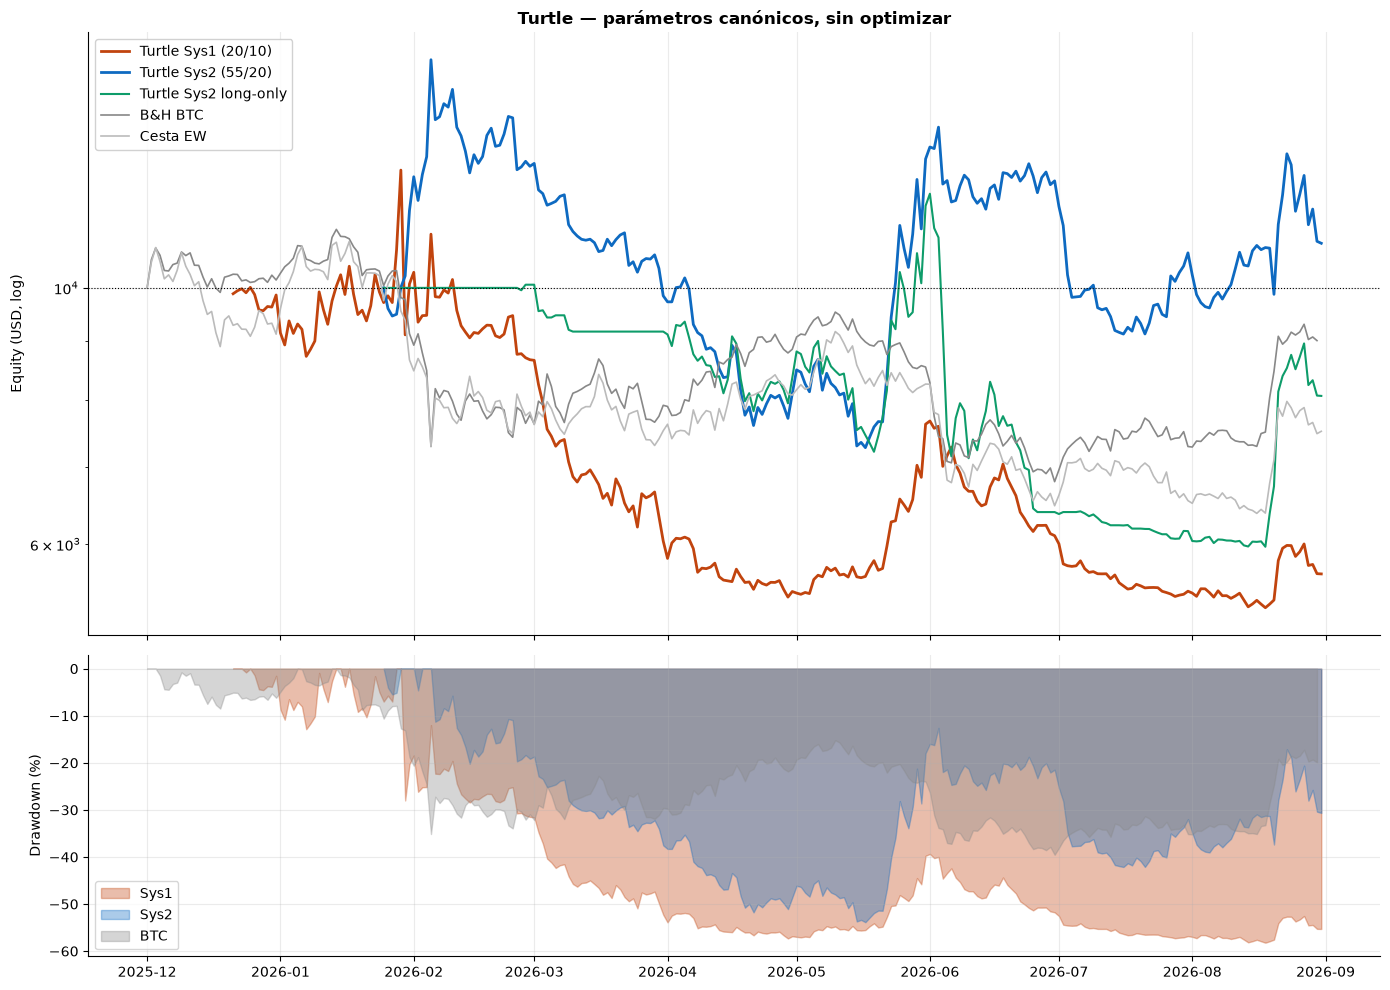

In [40]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[2, 1], sharex=True)

for ec, lab, c, lw in [(ec_s1,"Turtle Sys1 (20/10)","#c1440e",2),
                       (ec_s2,"Turtle Sys2 (55/20)","#0e6ac1",2),
                       (ec_s2lo,"Turtle Sys2 long-only","#0e9c6a",1.5),
                       (bh_btc,"B&H BTC","#888",1.2),
                       (bh_bask,"Cesta EW","#bbb",1.2)]: #,(bh_spy,"B&H SPY","#f0a202",1.2)]:
    ax[0].plot(ec.index, ec.values, label=lab, color=c, lw=lw)

ax[0].axhline(EQUITY_0, color="k", ls=":", lw=0.8)
ax[0].set_yscale("log"); ax[0].set_ylabel("Equity (USD, log)")
ax[0].set_title("Turtle — parámetros canónicos, sin optimizar", fontweight="bold")
ax[0].legend(loc="upper left", framealpha=0.9)

for ec, lab, c in [(ec_s1,"Sys1","#c1440e"), (ec_s2,"Sys2","#0e6ac1"), (bh_btc,"BTC","#888")]:
    ax[1].fill_between(ec.index, (ec/ec.cummax()-1)*100, 0, alpha=0.35, color=c, label=lab)
ax[1].set_ylabel("Drawdown (%)"); ax[1].legend(loc="lower left")
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout(); plt.show()

## 7. Walk-Forward Optimization

**Diseño:** ventanas rodantes ancladas al calendario.
- **In-sample (IS):** 365 días → se optimiza la rejilla de parámetros
- **Out-of-sample (OOS):** 90 días → se aplican los parámetros ganadores, sin tocar nada
- **Paso:** 90 días (las ventanas OOS no se solapan → track record OOS limpio y concatenable)

**Selección:** el criterio es Sharpe IS penalizado por drawdown, no Sharpe puro. Optimizar
Sharpe a secas selecciona sistemáticamente el parámetro más apalancado de la rejilla.

⚠️ Con ~5 años de datos y ventanas de 90d salen ~16 folds OOS. Para un sistema que vive de
capturar 2-3 tendencias grandes al año, **16 observaciones no son una muestra**. Trátalo como
un diagnóstico cualitativo, no como evidencia estadística.

In [41]:
# Rejilla de parámetros — deliberadamente pequeña.
# Rejillas grandes sobre 5 años de datos = overfitting garantizado.
GRID = [
    {"entry": e, "exit": x, "stop_n": sn, "risk": rk}
    for e, x in [(20,10), (55,20), (100,20), (360,10)]
    for sn in [1.0, 1.5, 2.0]
    for rk in [0.005, 0.01]
]
print(f"Combinaciones: {len(GRID)}")

# Pre-computar datasets por (entry, exit) — evita recalcular canales en cada fold
# (55,20) siempre presente: es el baseline canónico contra el que se compara cada fold
_pairs = sorted({(g["entry"], g["exit"]) for g in GRID} | {(55, 20)})
PREP = {p: {s: prepare(d, *p) for s, d in RAW.items()} for p in _pairs}
print(f"Datasets precomputados: {len(PREP)}")

Combinaciones: 24
Datasets precomputados: 4


In [42]:
def score_is(ec, penalty=0.5):
    """Sharpe IS penalizado por drawdown. Evita seleccionar el parámetro más apalancado."""
    m = metrics(ec)
    if not m or m["Volatilidad"] == 0: return -np.inf
    return m["Sharpe"] - penalty*abs(m["Max DD"])


def walk_forward(is_days=365, oos_days=90, grid=GRID, verbose=True):
    """WFO rodante. Devuelve (df_folds, equity_oos_concatenada)."""
    all_dates = sorted(set().union(*[set(d.index) for d in RAW.values()]))
    t0, tN = pd.Timestamp(all_dates[0]), pd.Timestamp(all_dates[-1])

    folds, oos_rets, cur = [], [], t0 + timedelta(days=is_days)
    while cur + timedelta(days=oos_days) <= tN:
        is_a, is_b = cur - timedelta(days=is_days), cur
        oos_a, oos_b = cur, cur + timedelta(days=oos_days)

        # --- optimizar IN-SAMPLE ---
        best, best_sc = None, -np.inf
        for g in grid:
            ec, _ = run_turtle(PREP[(g["entry"],g["exit"])], g["entry"], g["exit"],
                               stop_n=g["stop_n"], risk=g["risk"], start=is_a, end=is_b)
            sc = score_is(ec)
            if sc > best_sc: best_sc, best = sc, g

        # --- aplicar OUT-OF-SAMPLE (sin tocar nada) ---
        ec_o, tr_o = run_turtle(PREP[(best["entry"],best["exit"])], best["entry"], best["exit"],
                                stop_n=best["stop_n"], risk=best["risk"], start=oos_a, end=oos_b)
        # --- baseline canónico en la MISMA ventana OOS ---
        ec_b, _ = run_turtle(PREP[(55,20)], 55, 20, start=oos_a, end=oos_b)

        r_oos  = ec_o.iloc[-1]/ec_o.iloc[0]-1 if len(ec_o) > 1 else 0.0
        r_base = ec_b.iloc[-1]/ec_b.iloc[0]-1 if len(ec_b) > 1 else 0.0

        folds.append({"fold": len(folds)+1, "oos_ini": oos_a.date(), "oos_fin": oos_b.date(),
                      **{f"p_{k}": v for k, v in best.items()},
                      "IS_score": round(best_sc,3), "OOS_ret": r_oos,
                      "BASE_ret": r_base, "trades": len(tr_o)})
        if len(ec_o) > 1: oos_rets.append(ec_o.pct_change().dropna())
        if verbose:
            print(f"  Fold {len(folds):2d} | {oos_a.date()} → {oos_b.date()} | "
                  f"e{best['entry']}/x{best['exit']} sn{best['stop_n']} r{best['risk']} | "
                  f"OOS {r_oos:+7.2%} vs base {r_base:+7.2%}")
        cur += timedelta(days=oos_days)

    df = pd.DataFrame(folds)
    eq = (EQUITY_0*(1+pd.concat(oos_rets).sort_index()).cumprod()) if oos_rets else pd.Series(dtype=float)
    return df, eq

print("Ejecutando walk-forward (puede tardar varios minutos)...\n")
FOLDS, EC_WFO = walk_forward()

Ejecutando walk-forward (puede tardar varios minutos)...



In [43]:
display(FOLDS.style.format({"OOS_ret":"{:+.2%}","BASE_ret":"{:+.2%}","IS_score":"{:.3f}"})
        .background_gradient(subset=["OOS_ret"], cmap="RdYlGn", vmin=-0.3, vmax=0.3))

wins = (FOLDS.OOS_ret > FOLDS.BASE_ret).sum()
print(f"\n{'='*70}")
print(f"  WFO gana al baseline canónico en {wins}/{len(FOLDS)} folds ({wins/len(FOLDS):.0%})")
print(f"  Retorno OOS medio  — WFO: {FOLDS.OOS_ret.mean():+.2%} | baseline: {FOLDS.BASE_ret.mean():+.2%}")
print(f"  Folds OOS positivos— WFO: {(FOLDS.OOS_ret>0).mean():.0%} | baseline: {(FOLDS.BASE_ret>0).mean():.0%}")
print(f"{'='*70}")

# Test estadístico: ¿la diferencia es real o ruido?
from scipy import stats
d = FOLDS.OOS_ret - FOLDS.BASE_ret
t, p = stats.ttest_1samp(d, 0)
print(f"\n  t-test (WFO − baseline): t={t:.3f}, p={p:.3f}, n={len(d)}")
print(f"  → {'Diferencia NO significativa: la optimización es ruido.' if p > 0.05 else 'Diferencia significativa (ojo: n pequeño).'}")

# Estabilidad de parámetros: si saltan cada fold, no hay señal
print(f"\n  Estabilidad de parámetros elegidos:")
for c in ["p_entry","p_exit","p_stop_n","p_risk"]:
    vc = FOLDS[c].value_counts()
    print(f"    {c:<10}: {dict(vc)}  → moda {vc.iloc[0]/len(FOLDS):.0%} de los folds")

KeyError: "None of [Index(['OOS_ret'], dtype='str')] are in the [columns]"

AttributeError: 'DataFrame' object has no attribute 'OOS_ret'

IndexError: single positional indexer is out-of-bounds

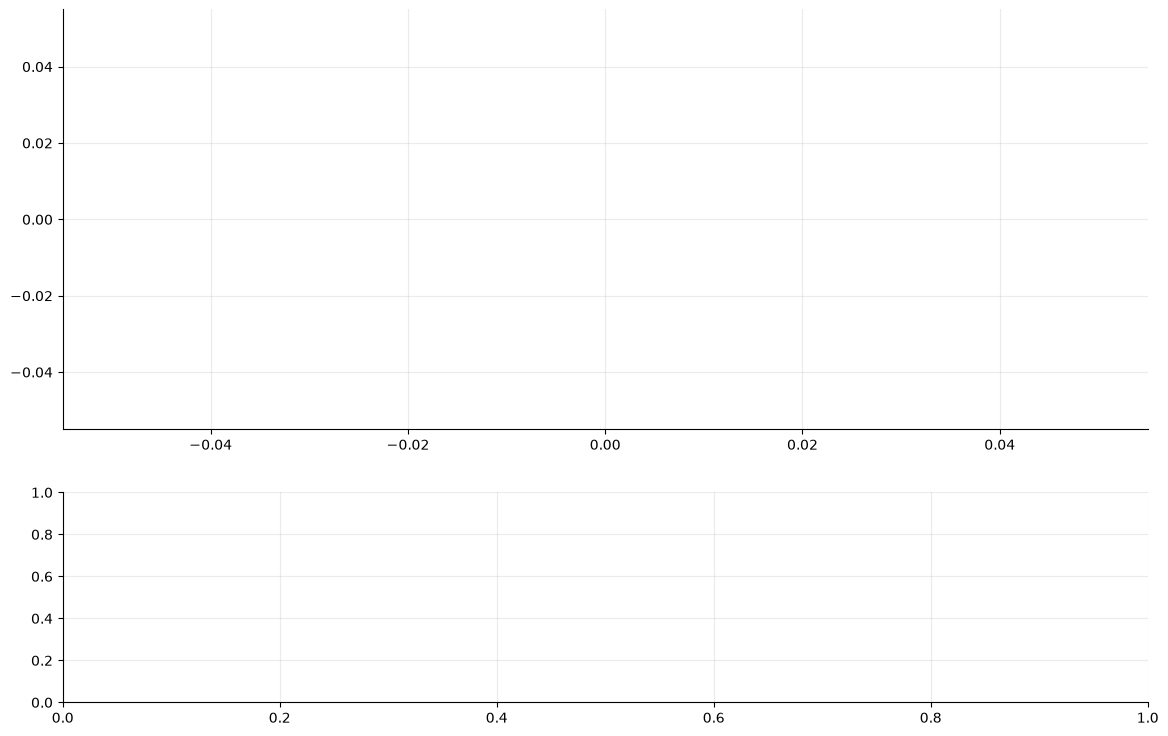

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[2,1])

ax[0].plot(EC_WFO.index, EC_WFO.values, label="Walk-Forward OOS (concatenado)", color="#c1440e", lw=2)
ec_b_full, _ = run_turtle(PREP[(55,20)], 55, 20)
_al = ec_b_full.reindex(EC_WFO.index).ffill()
ax[0].plot(_al.index, (_al/_al.iloc[0]*EQUITY_0).values, label="Turtle canónico 55/20 (fijo)",
           color="#0e6ac1", lw=2, ls="--")
_bt = bh_btc.reindex(EC_WFO.index).ffill()
ax[0].plot(_bt.index, (_bt/_bt.iloc[0]*EQUITY_0).values, label="B&H BTC", color="#999", lw=1.2)
ax[0].axhline(EQUITY_0, color="k", ls=":", lw=0.8)
ax[0].set_yscale("log"); ax[0].set_ylabel("Equity (USD, log)")
ax[0].set_title("Walk-Forward OOS vs. parámetros canónicos fijos", fontweight="bold")
ax[0].legend()

w = 0.38; x = np.arange(len(FOLDS))
ax[1].bar(x-w/2, FOLDS.OOS_ret*100, w, label="WFO", color="#c1440e")
ax[1].bar(x+w/2, FOLDS.BASE_ret*100, w, label="Canónico", color="#0e6ac1")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_xticks(x); ax[1].set_xticklabels(FOLDS.fold)
ax[1].set_xlabel("Fold OOS"); ax[1].set_ylabel("Retorno (%)"); ax[1].legend()
plt.tight_layout(); plt.show()

show(metrics(EC_WFO), "WALK-FORWARD OUT-OF-SAMPLE")

## 8. Cuantificación de sesgos

Aquí es donde el backtest se gana o pierde la credibilidad.

In [ ]:
# ── SESGO 1: SURVIVORSHIP ──
# Los activos listados tarde en Binance son, por construcción, los que "llegaron"
# después de sobrevivir. Si el sistema gana sobre todo en ellos, el edge es ilusorio.
print("="*72); print("  SESGO 1 — SURVIVORSHIP"); print("="*72)

first = pd.Timestamp(min(d.index[0] for d in RAW.values()))
veteranos = [s for s,d in RAW.items() if d.index[0] <= first + timedelta(days=180)]
nuevos    = [s for s in RAW if s not in veteranos]
print(f"\n  Veteranos (listados ≤{(first+timedelta(days=180)).date()}): {len(veteranos)}")
print(f"  Recientes: {len(nuevos)} → {nuevos}")

if len(veteranos) >= 5:
    ec_v, tr_v = run_turtle({s: DATA_S2[s] for s in veteranos}, 55, 20)
    show(metrics(ec_v, tr_v), "Solo VETERANOS (sesgo reducido)")
    show(metrics(ec_s2, tr_s2), "Universo COMPLETO (sesgado)")
    gap = metrics(ec_s2)["CAGR"] - metrics(ec_v)["CAGR"]
    print(f"\n  ⚠️  Diferencia de CAGR atribuible al sesgo: {gap:+.2%}")
    print("     Si es grande y positiva, tu 'edge' es en buena parte survivorship.")

  SESGO 1 — SURVIVORSHIP

  Veteranos (listados ≤2026-05-30): 49
  Recientes: 0 → []

  Solo VETERANOS (sesgo reducido)
  Retorno total         :    114.65%
  CAGR                  :    266.05%
  Volatilidad           :     90.80%
  Sharpe                :       2.93
  Sortino               :       5.57
  Max DD                :    -52.48%
  Calmar                :       5.07
  Días en DD>20%        :        137
  Años                  :       0.59
  Trades                :         94
  Win rate              :     10.64%
  Profit factor         :       1.04
  Payoff (W/L)          :       8.76
  Duración media (d)    :       9.26

  Universo COMPLETO (sesgado)
  Retorno total         :    114.65%
  CAGR                  :    266.05%
  Volatilidad           :     90.80%
  Sharpe                :       2.93
  Sortino               :       5.57
  Max DD                :    -52.48%
  Calmar                :       5.07
  Días en DD>20%        :        137
  Años                  :       0.5

  SESGO 2 — CONCENTRACIÓN DE P&L

  Top  1 trades = 770.9% del P&L total

  Top  3 trades = 1498.1% del P&L total

  Top  5 trades = 2094.8% del P&L total

  Top 10 trades = 2433.8% del P&L total

  P&L total: $453 en 94 trades
  Sin el mejor trade: $-3,038  (-30.4% sobre capital inicial)

  Mejores 5 trades:


,symbol,side,opened,closed,units,pnl,bars
0,BCH,-1,2026-05-16,2026-07-04,4,3490.319553,49
1,APE,-1,2026-01-25,2026-04-16,4,1796.207478,81
2,DOT,-1,2026-06-01,2026-08-21,4,1495.812393,81
3,LINK,-1,2026-01-25,2026-02-25,4,1401.087462,31
4,ADA,-1,2026-06-01,2026-07-04,4,1300.442616,33


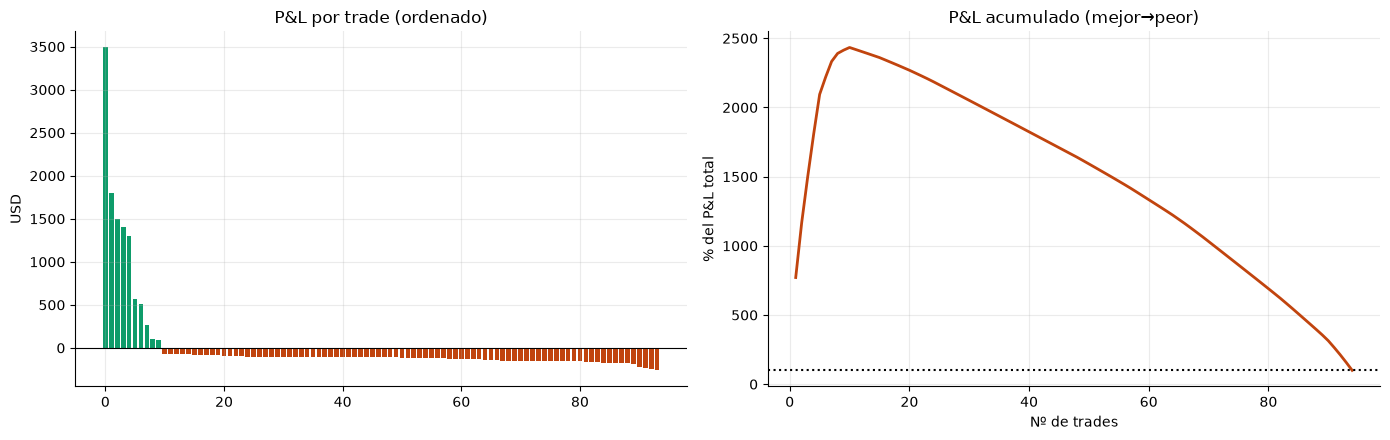

In [ ]:
# ── SESGO 2: CONCENTRACIÓN DE P&L ──
# Turtle vive de pocas tendencias enormes. Si 3 trades hacen todo el resultado,
# tu track record es una muestra de tamaño 3, no de tamaño N.
print("="*72); print("  SESGO 2 — CONCENTRACIÓN DE P&L"); print("="*72)
tr = tr_s2.sort_values("pnl", ascending=False).reset_index(drop=True)
tot = tr.pnl.sum()
for k in [1, 3, 5, 10]:
    if len(tr) >= k:
        print(f"\n  Top {k:>2} trades = {tr.pnl.head(k).sum()/tot:>6.1%} del P&L total")
print(f"\n  P&L total: ${tot:,.0f} en {len(tr)} trades")
print(f"  Sin el mejor trade: ${tot - tr.pnl.iloc[0]:,.0f}  "
      f"({(tot-tr.pnl.iloc[0])/EQUITY_0:+.1%} sobre capital inicial)")

print(f"\n  Mejores 5 trades:")
display(tr.head(5)[["symbol","side","opened","closed","units","pnl","bars"]])

fig, ax = plt.subplots(1, 2, figsize=(14,4.5))
ax[0].bar(range(len(tr)), tr.pnl.values, color=np.where(tr.pnl>0,"#0e9c6a","#c1440e"))
ax[0].set_title("P&L por trade (ordenado)"); ax[0].set_ylabel("USD"); ax[0].axhline(0,color="k",lw=.8)
ax[1].plot(np.arange(1,len(tr)+1), tr.pnl.cumsum().values/tot*100, color="#c1440e", lw=2)
ax[1].axhline(100, ls=":", color="k"); ax[1].set_title("P&L acumulado (mejor→peor)")
ax[1].set_xlabel("Nº de trades"); ax[1].set_ylabel("% del P&L total")
plt.tight_layout(); plt.show()

In [ ]:
# Cuanto es la pérdida máxima: mismo cuadro pero con los peores trades
print("="*72); print(" CONCENTRACIÓN DE P&L NEGATIVO"); print("="*72)

wr = tr_s2.sort_values("pnl", ascending=True).reset_index(drop=True)
tot = wr.pnl.sum()
for k in [1, 3, 5, 10]:
    if len(wr) >= k:
        print(f"\n  Bottom {k:>2} trades = {wr.pnl.head(k).sum()/tot:>6.1%} del P&L total")
print(f"\n  P&L total: ${tot:,.0f} en {len(tr)} trades")
print(f"  Sin el peor trade: ${tot - wr.pnl.iloc[0]:,.0f}  "
      f"({(tot-wr.pnl.iloc[0])/EQUITY_0:+.1%} sobre capital inicial)")

print(f"\n  Peores 20 trades:")
display(wr.head(20)[["symbol","side","opened","closed","units","pnl","bars"]])


 CONCENTRACIÓN DE P&L NEGATIVO

  Bottom  1 trades = -57.6% del P&L total

  Bottom  3 trades = -164.7% del P&L total

  Bottom  5 trades = -256.1% del P&L total

  Bottom 10 trades = -447.1% del P&L total

  P&L total: $453 en 94 trades
  Sin el peor trade: $713  (+7.1% sobre capital inicial)

  Peores 20 trades:


,symbol,side,opened,closed,units,pnl,bars
0,YM,-1,2026-03-05,2026-03-10,3,-260.669479,5
1,LPT,1,2026-04-10,2026-04-11,1,-249.425981,1
2,TY,1,2026-03-02,2026-03-03,1,-235.554224,1
3,ES,-1,2026-03-27,2026-04-01,2,-225.287546,5
4,ZG,-1,2026-03-23,2026-03-25,1,-188.704375,2
5,ATOM,1,2026-05-11,2026-05-14,3,-176.627150,3
6,YM,1,2026-07-01,2026-07-08,2,-173.229743,7
7,YM,1,2026-06-22,2026-06-26,2,-172.007960,4
8,RENDER,1,2026-05-25,2026-05-28,3,-171.718371,3
9,YM,1,2026-06-15,2026-06-18,2,-171.147828,3


In [ ]:
from IPython.display import display

# Peores meses (donde se agrupan mas stops). Hace resample de wr
wm = tr_s2.resample("ME", on="closed").agg(pnl=("pnl", "sum"), trades=("pnl", "size")).sort_values("pnl")
print(f"\n  Peores meses (resample por cierre):")
display(wm.head(10)[["pnl","trades"]])



  Peores meses (resample por cierre):


,pnl,trades
closed,,
2026-03-31,-3008.886669,22
2026-05-31,-1414.400345,14
2026-04-30,-645.187521,22
2026-06-30,-318.213648,8
2026-01-31,-310.220509,3
2026-08-31,1041.345159,8
2026-02-28,1863.471658,3
2026-07-31,3244.831697,14


  SESGO 3 — DIVERSIFICACIÓN ILUSORIA

  Símbolos de partida       : 49
  Descartados (var. nula)   : ['MKR']   ← precio congelado

  Activos en cartera        : 48
  Observaciones / activos   : 5.6   ⚠ <10: matriz mal condicionada, n_eff sesgado AL ALZA
  Correlación media (par)   : 0.458
  Correlación mediana       : 0.524
  % pares con corr > 0.70   : 13.8%
  PC1 explica               : 53.6% de la varianza

  ➜ Nº EFECTIVO de apuestas independientes: 3.4
     Crees tener 48 mercados. Tienes ~3.
     Turtle funcionaba con ~20 futuros genuinamente descorrelacionados.


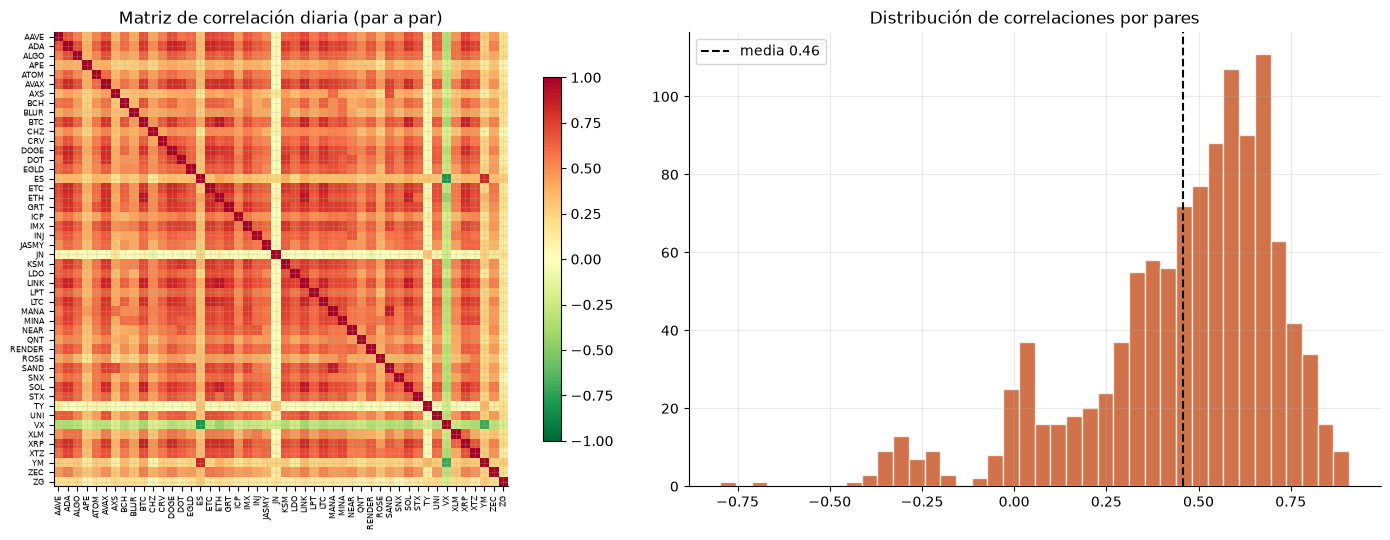

In [ ]:
# ── SESGO 3: CORRELACIÓN — ¿cuántas apuestas independientes hay realmente? ──
print("="*72); print("  SESGO 3 — DIVERSIFICACIÓN ILUSORIA"); print("="*72)

MIN_OBS     = 120   # barras mínimas por símbolo para estimar su fila
MIN_OVERLAP = 60    # solapamiento mínimo por PAR para aceptar esa correlación

# `aligned` (el inner join de §6) NO sirve aquí. Con el universo completo la
# intersección de calendarios es VACÍA —lo dice la propia §6— así que
# `.pct_change().dropna()` devolvía 0 filas, `.corr()` una matriz NxN de NaN y
# `eigvalsh` reventaba con "Eigenvalues did not converge": LAPACK no valida su
# entrada, un NaN dentro no es un error de dominio legible sino no-convergencia.
#
# Se estima igual que la cesta EW de §6: retorno sobre el índice PROPIO de cada
# símbolo y unión de calendarios. Aquí un NaN significa "mercado cerrado", no
# "dato perdido", así que la correlación va PAR A PAR (`min_periods`): cripto vs
# cripto usa los 7 días de la semana; cripto vs TradFi solo los hábiles comunes.
# Es el estimador que más información usa, a cambio de que la matriz resultante
# ya no sea semidefinida positiva (cada celda ve una muestra distinta) — se
# corrige abajo.
rets = pd.DataFrame({s: d["close"].pct_change(fill_method=None) for s, d in RAW.items()})
rets = rets.replace([np.inf, -np.inf], np.nan)
n_sym0 = rets.shape[1]

# 1) Fuera los símbolos sin muestra suficiente para estimar nada.
thin = rets.columns[rets.count() < MIN_OBS].tolist()
rets = rets.drop(columns=thin)

# 2) Fuera los de varianza nula: contrato muerto con precio congelado
#    (skill /turtle-trading §13.8). std = 0 ⇒ correlación indefinida ⇒ columna
#    entera de NaN ⇒ mismo crash. Es la causa silenciosa, no la del calendario.
flat = rets.columns[rets.std(skipna=True).fillna(0) == 0].tolist()
rets = rets.drop(columns=flat)

corr = rets.corr(min_periods=MIN_OVERLAP)

# 3) Poda iterativa por falta de solapamiento: quita primero el símbolo con más
#    pares sin estimar. Conserva más activos que un dropna(how="any") de golpe,
#    que se llevaría por delante a los sanos que solo chocan con el intruso.
dropped = []
while len(corr) > 2 and corr.isna().any().any():
    worst = corr.isna().sum().idxmax()
    corr = corr.drop(index=worst, columns=worst)
    dropped.append(worst)

if len(corr) < 3:
    print(f"\n  ✗ No se puede estimar: solo {len(corr)} activos con solapamiento "
          f"suficiente (MIN_OVERLAP={MIN_OVERLAP}).")
    print(f"     Baja el umbral o acota el universo a un grupo de correlación.")
    n_eff, off = np.nan, np.array([])
else:
    C = (corr.values + corr.values.T) / 2          # simetriza el ruido numérico
    ev_raw = np.linalg.eigvalsh(C)

    # Proyección a la matriz de correlación válida más cercana: clip de
    # autovalores negativos + rediagonalización a 1. Sin esto, `ev[ev>0]`
    # descartaba masa de la traza y el "% que explica PC1" salía inflado.
    psd_fix = ev_raw.min() < -1e-10
    if psd_fix:
        w, V = np.linalg.eigh(C)
        C = V @ np.diag(np.clip(w, 0, None)) @ V.T
        d = np.sqrt(np.diag(C)); C = C / np.outer(d, d)
        np.fill_diagonal(C, 1.0)

    ev = np.linalg.eigvalsh(C)[::-1]
    ev = ev[ev > 1e-12]
    n_eff = (ev.sum()**2) / (ev**2).sum()

    corr = pd.DataFrame(C, index=corr.index, columns=corr.columns)
    off  = C[np.triu_indices_from(C, 1)]

    # --- de qué se ha estimado, antes de creerse el número ---
    print(f"\n  Símbolos de partida       : {n_sym0}")
    if thin:    print(f"  Descartados (muestra <{MIN_OBS}) : {thin}")
    if flat:    print(f"  Descartados (var. nula)   : {flat}   ← precio congelado")
    if dropped: print(f"  Descartados (sin solape)  : {dropped}")
    if psd_fix: print(f"  Matriz par-a-par no PSD (λ_min={ev_raw.min():+.4f}) → proyectada")

    T_N = rets.shape[0] / len(corr)
    print(f"\n  Activos en cartera        : {len(corr)}")
    print(f"  Observaciones / activos   : {T_N:.1f}"
          f"{'   ⚠ <10: matriz mal condicionada, n_eff sesgado AL ALZA' if T_N < 10 else ''}")
    print(f"  Correlación media (par)   : {off.mean():.3f}")
    print(f"  Correlación mediana       : {np.median(off):.3f}")
    print(f"  % pares con corr > 0.70   : {(off>0.70).mean():.1%}")
    print(f"  PC1 explica               : {ev[0]/ev.sum():.1%} de la varianza")
    print(f"\n  ➜ Nº EFECTIVO de apuestas independientes: {n_eff:.1f}")
    print(f"     Crees tener {len(corr)} mercados. Tienes ~{n_eff:.0f}.")
    print(f"     Turtle funcionaba con ~20 futuros genuinamente descorrelacionados.")

    fig, ax = plt.subplots(1, 2, figsize=(15,5.5))
    im = ax[0].imshow(corr.values, cmap="RdYlGn_r", vmin=-1, vmax=1)
    ax[0].set_xticks(range(len(corr))); ax[0].set_xticklabels(corr.columns, rotation=90, fontsize=6)
    ax[0].set_yticks(range(len(corr))); ax[0].set_yticklabels(corr.columns, fontsize=6)
    ax[0].set_title("Matriz de correlación diaria (par a par)"); plt.colorbar(im, ax=ax[0], shrink=.8)
    ax[1].hist(off, bins=40, color="#c1440e", alpha=.75, edgecolor="w")
    ax[1].axvline(off.mean(), color="k", ls="--", label=f"media {off.mean():.2f}")
    ax[1].set_title("Distribución de correlaciones por pares"); ax[1].legend()
    plt.tight_layout(); plt.show()

In [ ]:
# ── SESGO 4: SENSIBILIDAD A COSTES ──
# Si el edge muere al doblar el slippage, no era un edge.
print("="*72); print("  SESGO 4 — SENSIBILIDAD A COSTES"); print("="*72)

rows = []
for lbl, f, sl, fd in [("Sin costes",0,0,0), ("Optimista",0.0002,0.0005,0.0001),
                       ("Base",TAKER_FEE,SLIPPAGE,FUNDING_DIA),
                       ("Pesimista",0.0005,0.0025,0.0005), ("Estrés",0.001,0.005,0.001)]:
    ec_c, tr_c = run_turtle(DATA_S2, 55, 20, fee=f, slip=sl, funding=fd)
    m = metrics(ec_c, tr_c)
    rows.append({"Escenario":lbl, "Fee(bps)":f*1e4, "Slip(bps)":sl*1e4,
                 "Funding(%/a)":round(fd*365*100,1), "CAGR":m["CAGR"],
                 "Sharpe":m["Sharpe"], "MaxDD":m["Max DD"]})

cost_df = pd.DataFrame(rows)
display(cost_df.style.format({"CAGR":"{:+.2%}","MaxDD":"{:.1%}","Sharpe":"{:.2f}"})
        .background_gradient(subset=["CAGR"], cmap="RdYlGn"))

deg = cost_df.CAGR.iloc[0] - cost_df.CAGR.iloc[2]
print(f"\n  Coste de fricción: {deg:.2%} de CAGR (sin costes → base)")
print(f"  {'⚠️  El edge NO sobrevive costes realistas.' if cost_df.CAGR.iloc[3] <= 0 else '✓ El edge sobrevive el escenario pesimista.'}")

  SESGO 4 — SENSIBILIDAD A COSTES


,Escenario,Fee(bps),Slip(bps),Funding(%/a),CAGR,Sharpe,MaxDD
0,Sin costes,0.000000,0.000000,0.000000,+342.42%,3.86,-47.2%
1,Optimista,2.000000,5.000000,3.700000,+300.98%,3.09,-50.0%
2,Base,5.000000,10.000000,11.000000,+266.05%,2.93,-52.5%
3,Pesimista,5.000000,25.000000,18.200000,-18.53%,-0.25,-63.0%
4,Estrés,10.000000,50.000000,36.500000,-30.97%,-0.47,-59.1%



  Coste de fricción: 76.37% de CAGR (sin costes → base)
  ⚠️  El edge NO sobrevive costes realistas.


## 9. Monte Carlo — ¿qué tan afortunada fue esta secuencia?

Remuestreamos el orden de los trades 5.000 veces. La curva que viste es **una** realización
de un proceso estocástico. Lo relevante es la distribución, no el camino que tocó.

  Simulaciones: 5,000 | Capital inicial: $10,000

  Percentil       Equity final      Max DD
  ----------------------------------------
  p5                    3,237     -75.1%
  p25                   7,060     -50.4%
  p50                  10,086     -36.0%
  p75                  13,660     -25.4%
  p95                  19,116     -15.9%

  Prob. de terminar en pérdida : 49.3%
  Prob. de DD ≥ 50% (bust)     : 25.5%
  Peor caso simulado           : $-1,171 (DD -111.7%)


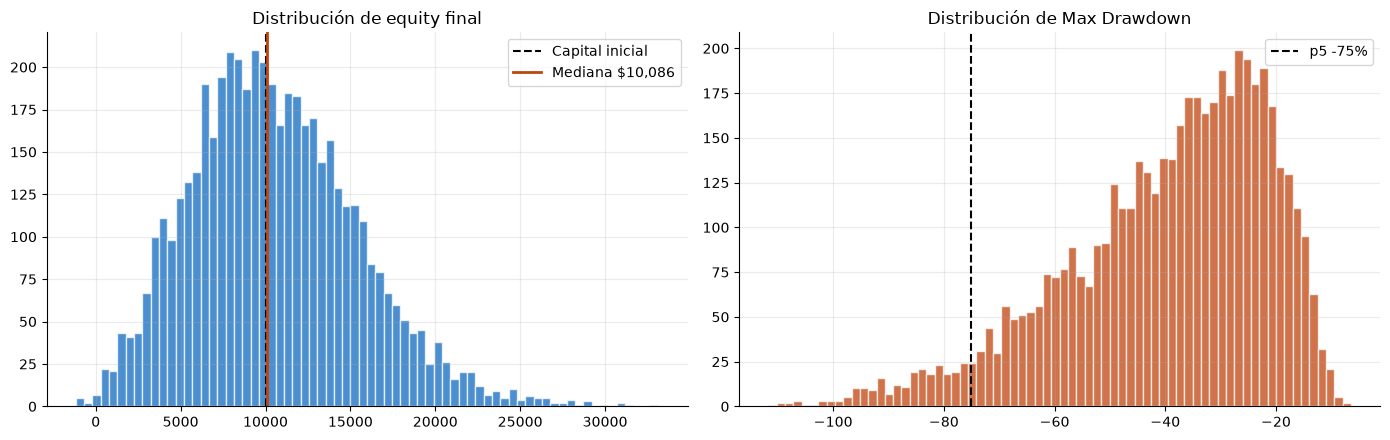

In [ ]:
def mc_trades(trades, n_sims=5000, eq0=EQUITY_0, bust=-0.50, seed=7):
    """Bootstrap CON REEMPLAZO de los trades.

    Nota: permutar el orden NO sirve — la suma de P&L es invariante y el equity
    final sale idéntico en todas las simulaciones. Solo el remuestreo con
    reemplazo genera una distribución real de resultados finales.
    """
    pnl = trades.pnl.values
    if len(pnl) < 10: return None
    rng = np.random.default_rng(seed)
    finals, dds, busts = [], [], 0
    for _ in range(n_sims):
        p = rng.choice(pnl, size=len(pnl), replace=True)   # ← con reemplazo
        eq = eq0 + np.cumsum(p)
        peak = np.maximum.accumulate(np.concatenate([[eq0], eq]))
        dd = ((np.concatenate([[eq0], eq]) - peak)/peak).min()
        finals.append(eq[-1]); dds.append(dd)
        if dd <= bust: busts += 1
    return {"finals": np.array(finals), "dds": np.array(dds), "p_bust": busts/n_sims}

mc = mc_trades(tr_s2)
if mc:
    f, d = mc["finals"], mc["dds"]
    print(f"  Simulaciones: 5,000 | Capital inicial: ${EQUITY_0:,}\n")
    print(f"  {'Percentil':<12}{'Equity final':>16}{'Max DD':>12}")
    print(f"  {'-'*40}")
    for q in [5,25,50,75,95]:
        print(f"  p{q:<11}{np.percentile(f,q):>15,.0f}{np.percentile(d,q):>11.1%}")
    print(f"\n  Prob. de terminar en pérdida : {(f < EQUITY_0).mean():.1%}")
    print(f"  Prob. de DD ≥ 50% (bust)     : {mc['p_bust']:.1%}")
    print(f"  Peor caso simulado           : ${f.min():,.0f} (DD {d.min():.1%})")

    fig, ax = plt.subplots(1,2, figsize=(14,4.5))
    ax[0].hist(f, bins=70, color="#0e6ac1", alpha=.75, edgecolor="w")
    ax[0].axvline(EQUITY_0, color="k", ls="--", label="Capital inicial")
    ax[0].axvline(np.median(f), color="#c1440e", lw=2, label=f"Mediana ${np.median(f):,.0f}")
    ax[0].set_title("Distribución de equity final"); ax[0].legend()
    ax[1].hist(d*100, bins=70, color="#c1440e", alpha=.75, edgecolor="w")
    ax[1].axvline(np.percentile(d,5)*100, color="k", ls="--", label=f"p5 {np.percentile(d,5):.0%}")
    ax[1].set_title("Distribución de Max Drawdown"); ax[1].legend()
    plt.tight_layout(); plt.show()

## 10. Tabla comparativa y veredicto

In [ ]:
comp = pd.DataFrame({
    "Turtle Sys1 (20/10)":  metrics(ec_s1, tr_s1),
    "Turtle Sys2 (55/20)":  metrics(ec_s2, tr_s2),
    "Turtle Sys2 long-only":metrics(ec_s2lo, tr_s2lo),
    "Walk-Forward OOS":     metrics(EC_WFO),
    "B&H BTC":              metrics(bh_btc),
    "Cesta EW":             metrics(bh_bask),
}).T[["CAGR","Volatilidad","Sharpe","Sortino","Max DD","Calmar","Retorno total"]]

comp.loc["COIN50 (oficial)"] = [0.1534, 0.6391, 0.48, 0.68, -0.7828, 0.1534/0.7828, 1.1926]

display(comp.style.format({c:"{:.2%}" for c in ["CAGR","Volatilidad","Max DD","Retorno total"]}
        | {c:"{:.2f}" for c in ["Sharpe","Sortino","Calmar"]})
        .background_gradient(subset=["Sharpe","Calmar"], cmap="RdYlGn"))

comp.to_csv("turtle_coin50_resultados.csv")
FOLDS.to_csv("turtle_coin50_walkforward_folds.csv", index=False)
tr_s2.to_csv("turtle_coin50_trades.csv", index=False)
print("\n✓ Exportado: turtle_coin50_resultados.csv / _walkforward_folds.csv / _trades.csv")

,CAGR,Volatilidad,Sharpe,Sortino,Max DD,Calmar,Retorno total
Turtle Sys1 (20/10),-44.87%,73.43%,-0.61,-0.83,-61.66%,-0.73,-33.47%
Turtle Sys2 (55/20),266.05%,90.80%,2.93,5.57,-52.48%,5.07,114.65%
Turtle Sys2 long-only,-4.92%,76.59%,-0.06,-0.08,-50.47%,-0.10,-2.92%
Walk-Forward OOS,nan%,nan%,nan,nan,nan%,nan,nan%
B&H BTC,-10.88%,45.72%,-0.24,-0.34,-39.59%,-0.27,-8.16%
Cesta EW,-28.87%,50.39%,-0.57,-0.91,-41.85%,-0.69,-22.26%
COIN50 (oficial),15.34%,63.91%,0.48,0.68,-78.28%,0.20,119.26%



✓ Exportado: turtle_coin50_resultados.csv / _walkforward_folds.csv / _trades.csv


In [ ]:
print("="*74)
print("  CHECKLIST DE VALIDEZ — responde SÍ a todo antes de arriesgar capital")
print("="*74)

chk = [
    ("WFO supera al canónico fijo en >60% de folds", wins/len(FOLDS) > 0.60),
    ("Diferencia WFO vs canónico estadísticamente significativa", p < 0.05),
    ("Parámetros estables entre folds (moda >50%)",
     FOLDS.p_entry.value_counts().iloc[0]/len(FOLDS) > 0.50),
    ("Edge sobrevive el escenario pesimista de costes", cost_df.CAGR.iloc[3] > 0),
    ("Top-3 trades <50% del P&L total", tr.pnl.head(3).sum()/tot < 0.50),
    ("Nº efectivo de apuestas independientes ≥ 8", n_eff >= 8),
    ("Sharpe OOS > Sharpe de B&H BTC", metrics(EC_WFO).get("Sharpe",0) > metrics(bh_btc)["Sharpe"]),
    ("Prob. Monte Carlo de bust (DD≥50%) < 20%", (mc["p_bust"] < 0.20) if mc else False),
]
for txt, ok in chk:
    print(f"  [{'✓' if ok else '✗'}] {txt}")

n_ok = sum(o for _, o in chk)
print(f"\n  {n_ok}/{len(chk)} criterios superados")
print(f"\n  {'→ Sigue investigando, pero hay algo.' if n_ok >= 6 else '→ NO despliegues capital. El backtest no soporta el peso.'}")
print("="*74)

  CHECKLIST DE VALIDEZ — responde SÍ a todo antes de arriesgar capital


NameError: name 'wins' is not defined

---

## 11. Qué hacer con esto

**Si el checklist salió mal (lo más probable):** eso es información valiosa, no un fracaso.
Significa que ahorraste el coste de descubrirlo con dinero real.

**Los tres problemas estructurales que ningún ajuste de parámetros arregla:**

1. **El universo no está diversificado.** El número efectivo de apuestas independientes
   (§8) es la cifra que más importa. Turtle funcionaba con ~20 futuros genuinamente
   descorrelacionados: bonos, divisas, metales, energía, softs. Cripto es *un solo trade*
   con 49 tickers. Cuando BTC cae, todo cae junto y los límites de 4/6/12 unidades no
   te protegen porque las unidades están correlacionadas entre sí.

2. **La muestra es demasiado corta.** Trend-following captura 2-3 tendencias grandes al año.
   Con 5 años tienes ~12 eventos relevantes. Los Turtles originales tenían décadas de datos
   de futuros para construir confianza en las reglas. Tú no.

3. **El walk-forward contradice la premisa de Turtle.** Dennis dijo explícitamente que las
   reglas podían publicarse en el periódico sin que nadie las siguiera, porque el problema
   es la disciplina, no los parámetros. Optimizar la ventana de ruptura cada 90 días es
   exactamente el comportamiento que hacía fracasar a los Turtles que fallaron.

**Direcciones más prometedoras que seguir optimizando esto:**
- Añadir clases de activo genuinamente descorrelacionadas (el sesgo #3 desaparece)
- Filtro de régimen (trend-following solo cuando la vol cross-sectional lo justifica)
- Reducir `RISK_PER_UNIT` a 0.5% — con correlación 0.7+ el 1% real es ~3% efectivo
- Comparar contra tu estrategia de pairs trading ya en producción (§`gcp_deploy.md`),
  que sí opera sobre relaciones cointegradas y no sobre beta direccional

---

*Reglas: Curtis Faith,* The Original Turtle Trading Rules *(2003) · Implementación: skill `/turtlerisk`*
*Datos: Binance USD-M Futures · Universo: COIN50 (MarketVector/Coinbase) · Benchmark: COIN50 oficial*


In [ ]:
# ── Libro abierto al final de la simulación ────────────────────────────────
# El motor devuelve (curva, trades CERRADOS): las posiciones vivas el último día
# no aparecen en ninguna de las dos. Se re-ejecuta Sys2 con `open_book` para
# capturarlas. El P&L de estas posiciones es NO REALIZADO: está marcado al
# último cierre, no a un fill, y no descuenta la comisión de salida.

BOOK = {}
_ec_s2, _tr_s2 = run_turtle(DATA_S2, SYS2["entry"], SYS2["exit"], open_book=BOOK)

ASOF = BOOK["asof"]
pnl_hist = (tr_s2.groupby("symbol").pnl.sum() if len(tr_s2)
            else pd.Series(dtype=float))                      # realizado histórico por símbolo

rows = []
for s, pos_ in BOOK["positions"].items():
    px      = BOOK["last_close"][s]                            # último cierre conocido
    ult_bar = DATA_S2[s].index[-1]                             # última barra del símbolo
    qty     = pos_.qty
    avg     = pos_.cost / qty if qty else np.nan
    upnl    = pos_.side * (px * qty - pos_.cost)               # bruto, sin fee de salida
    rows.append({
        "symbol": s,
        "grupo": SYM2GROUP.get(s, "otro"),
        "lado": "LARGO" if pos_.side > 0 else "CORTO",
        "unidades": pos_.nu,
        "qty": qty,
        "precio_medio": avg,
        "ultimo_cierre": px,
        "notional": qty * px,
        "stop": pos_.stop,
        "dist_stop_N": abs(px - pos_.stop) / pos_.n_entry if pos_.n_entry else np.nan,
        "N_entrada": pos_.n_entry,
        "abierta": pos_.opened,
        "dias": (ASOF - pos_.opened).days,
        "pnl_no_realizado": upnl,
        "pnl_pct_notional": upnl / (qty * avg) if qty and avg else np.nan,
        "datos_al": ult_bar,
        "stale": ult_bar < ASOF - pd.Timedelta(days=7),        # contrato sin datos recientes
        "pnl_realizado_hist": float(pnl_hist.get(s, 0.0)),     # cerrado previamente en ese símbolo
    })

POSICIONES = pd.DataFrame(rows)
if len(POSICIONES):
    POSICIONES = (POSICIONES.sort_values("pnl_no_realizado", ascending=False)
                            .reset_index(drop=True))

cash   = BOOK["cash"]                                          # equity realizado (sin marcar)
upnl_t = POSICIONES.pnl_no_realizado.sum() if len(POSICIONES) else 0.0
gross  = POSICIONES.notional.sum() if len(POSICIONES) else 0.0
eq_mtm = cash + upnl_t

print("=" * 78)
print(f"  LIBRO ABIERTO — Sistema 2 (55/20) al {ASOF.date()}")
print("=" * 78)
print(f"  Posiciones abiertas   : {len(POSICIONES)}"
      f"  ({(POSICIONES.lado=='LARGO').sum() if len(POSICIONES) else 0} largas /"
      f" {(POSICIONES.lado=='CORTO').sum() if len(POSICIONES) else 0} cortas)")
print(f"  Unidades              : {POSICIONES.unidades.sum() if len(POSICIONES) else 0}"
      f"  (tope dirección {MAX_DIR_UNITS}, grupo {MAX_CORR_UNITS})")
print(f"  Nocional bruto        : ${gross:,.0f}   ({gross/eq_mtm:.2f}x equity, tope {MAX_GROSS_LEV}x)")
print(f"  Equity realizado      : ${cash:,.0f}")
print(f"  P&L no realizado      : ${upnl_t:,.0f}   ({upnl_t/eq_mtm:.1%} del equity)")
print(f"  Equity marcado        : ${eq_mtm:,.0f}   (= curva: ${ec_s2.iloc[-1]:,.0f})")
print(f"  P&L realizado acumul. : ${tr_s2.pnl.sum():,.0f} en {len(tr_s2)} trades cerrados")

if len(POSICIONES):
    if POSICIONES.stale.any():
        print(f"\n  ⚠ Sin datos recientes (contrato muerto / precio congelado): "
              f"{POSICIONES.loc[POSICIONES.stale, 'symbol'].tolist()}")
    cols = ["symbol","grupo","lado","unidades","qty","precio_medio","ultimo_cierre",
            "notional","stop","dist_stop_N","abierta","dias","pnl_no_realizado",
            "pnl_pct_notional","pnl_realizado_hist"]
    display(POSICIONES[cols].style.format({
        "qty":"{:,.4f}", "precio_medio":"{:,.4f}", "ultimo_cierre":"{:,.4f}",
        "notional":"${:,.0f}", "stop":"{:,.4f}", "dist_stop_N":"{:.2f}N",
        "abierta":"{:%Y-%m-%d}", "pnl_no_realizado":"${:,.0f}",
        "pnl_pct_notional":"{:.1%}", "pnl_realizado_hist":"${:,.0f}",
    }).background_gradient(subset=["pnl_no_realizado"], cmap="RdYlGn"))

    # Exposición por grupo de correlación: el número que decide si esto está
    # diversificado o es un solo trade repetido (§8, §11).
    expo = (POSICIONES.groupby(["grupo","lado"])
            .agg(posiciones=("symbol","size"), unidades=("unidades","sum"),
                 notional=("notional","sum"), pnl_no_realizado=("pnl_no_realizado","sum")))
    display(expo)

    POSICIONES.to_csv(f"turtle_posiciones_{ASOF:%Y%m%d}.csv", index=False)
    print(f"\n✓ Exportado: turtle_posiciones_{ASOF:%Y%m%d}.csv")
else:
    print("\n  Sin posiciones abiertas al cierre de la simulación.")


  LIBRO ABIERTO — Sistema 2 (55/20) al 2026-08-28
  Posiciones abiertas   : 4  (4 largas / 0 cortas)
  Unidades              : 16  (tope dirección 12, grupo 6)
  Nocional bruto        : $68,383   (3.18x equity, tope 4.0x)
  Equity realizado      : $9,201
  P&L no realizado      : $12,287   (57.2% del equity)
  Equity marcado        : $21,488   (= curva: $21,488)
  P&L realizado acumul. : $453 en 94 trades cerrados


,symbol,grupo,lado,unidades,qty,precio_medio,ultimo_cierre,notional,stop,dist_stop_N,abierta,dias,pnl_no_realizado,pnl_pct_notional,pnl_realizado_hist
0,LINK,crypto,LARGO,4,"1,435.0521",9.0969,11.6840,"$16,767",9.0410,9.48N,2026-08-12,16,"$3,713",28.4%,"$1,401"
1,SOL,crypto,LARGO,4,159.5192,85.9024,104.9300,"$16,738",85.4059,7.79N,2026-08-19,9,"$3,035",22.2%,$0
2,BTC,crypto,LARGO,4,0.2554,"68,254.0354","79,276.5000","$20,248","67,965.8538",7.22N,2026-08-19,9,"$2,815",16.1%,$-85
3,ETH,crypto,LARGO,4,5.8567,"2,032.7147","2,497.7800","$14,629","2,018.7316",7.01N,2026-08-19,9,"$2,724",22.9%,$-125


,,posiciones,unidades,notional,pnl_no_realizado
grupo,lado,,,,
crypto,LARGO,4,16,68382.561862,12286.983627



✓ Exportado: turtle_posiciones_20260828.csv
